# Trường học

Nối tiếp `eda_thamquan.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_thamquan.parquet`.

Năm lớp trước đều có chung một điểm yếu chí mạng: **không lớp nào có thước ngoài**. Mọi
"recall 100%" đều là tự kiểm bằng chính tín hiệu đã tuyển, và mọi con số precision đều là
ước lượng bằng mắt.

Lớp này là lớp ĐẦU TIÊN trong chuỗi thoát khỏi chuyện đó, và lý do nằm ở đặc thù dữ liệu
giáo dục: **cấp học được mã hoá HAI LẦN.** Nhưng phải nói thẳng từ đầu — thẩm định độc lập
(2026-08-09) chỉ ra *hai lần mã hoá* KHÔNG đồng nghĩa *hai nhân chứng độc lập*:

| nguồn | ví dụ | phủ | độc lập với tên? |
|---|---|---|---|
| **TÊN tiếng Việt** | "Trường THCS Nguyễn Du", "Trường Mầm non Hoa Sen" | 54% | — |
| **TAG có cấu trúc** | `grades=6-9`, `isced:level=2` | ~8% | **CÓ** — số lớp gõ tay |
| **TAG preset** | `amenity=kindergarten`, `amenity=university` | ~16% | **KHÔNG** — preset người map bấm SAU KHI đọc tên |

Đo TỶ LỆ NHẤT TRÍ giữa tên và tag vẫn là con số precision thật đầu tiên của chuỗi, nhưng
**chỉ lát `grades`/`isced:level` được phép gọi là đối chứng ĐỘC LẬP** — phép phân rã nằm ở
bước 2, và mọi trích dẫn phải lấy con số của lát đó, không lấy số gộp. Chỗ hai nguồn *bất
đồng* cũng có giá trị ngang: đó là danh sách dòng cần soi tay, ngắn và có địa chỉ rõ ràng.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "truonghoc"
LOP_TRUOC = "thamquan"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "amenity",
    "building",
    "landuse",
    "office",
    "shop",
    "leisure",
    "tourism",
    "healthcare",
    "historic",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "craft",
    "place",
    "military",
    "religion",
]:
    poi[k] = tag(k)
for k in ["education", "grades", "isced:level", "operator:type", "operator"]:
    poi[k.replace(":", "_")] = td.map(lambda t, k=k: t.get(k))

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)

bộ vào: 162,669 dòng | polygon 37% | có tên 45%


## Chân dung hình thái

In [2]:
_uv = poi[
    poi["amenity"].isin(
        [
            "school",
            "kindergarten",
            "college",
            "university",
            "language_school",
            "driving_school",
            "music_school",
            "childcare",
            "prep_school",
        ]
    )
    | poi["building"].isin(["school", "university", "college", "kindergarten"])
    | poi["landuse"].eq("education")
    | name_norm.str.contains(
        r"truong |\bthcs\b|\bthpt\b|tieu hoc|mam non|mau giao|dai hoc|cao dang", na=False
    )
]
print(
    f"ứng viên thô: {len(_uv):,} | polygon {_uv['is_area'].mean():.0%}"
    f" | có tên {_uv['name'].notna().mean():.0%} | n_tags trung vị {_uv['n_tags'].median():.0f}"
)

print("\n── độ phủ của HAI hệ mã hoá cấp học ──")
for k, nhan in [
    ("education", "education=*"),
    ("grades", "grades=* (khoảng lớp)"),
    ("isced_level", "isced:level=*"),
    ("operator_type", "operator:type=*"),
]:
    v = _uv[k].value_counts()
    print(
        f"  {nhan:26s} {_uv[k].notna().sum():5,} ({_uv[k].notna().mean():5.1%}) → {v.head(6).to_dict()}"
    )

print("\n── các họ tag ứng viên ──")
for k in ["amenity", "building", "landuse", "office"]:
    v = poi[k].value_counts()
    print(f"  {k:9s} {v.sum():6,} → {v.head(8).to_dict()}")

ứng viên thô: 13,480 | polygon 78% | có tên 68% | n_tags trung vị 3

── độ phủ của HAI hệ mã hoá cấp học ──
  education=*                2,314 (17.2%) → {'school': 1409, 'kindergarten': 525, 'university': 176, 'college': 136, 'language_school': 47, 'driving_school': 8}
  grades=* (khoảng lớp)      1,085 ( 8.0%) → {'1-5': 445, '6-9': 321, '10-12': 240, '1-12': 26, '6-12': 13, '1-9': 11}
  isced:level=*                121 ( 0.9%) → {'1': 49, '2': 44, '3': 19, '1;2;3': 3, '0': 2, '1;2': 2}
  operator:type=*              147 ( 1.1%) → {'public': 29, 'public/government': 29, 'university': 26, 'government': 23, 'private': 17, 'military': 8}

── các họ tag ứng viên ──
  amenity   40,456 → {'restaurant': 7025, 'cafe': 5761, 'school': 4615, 'atm': 2667, 'bank': 1776, 'fuel': 1729, 'parking': 1476, 'pharmacy': 1341}
  building  16,765 → {'yes': 6121, 'school': 3301, 'industrial': 1837, 'hospital': 1054, 'university': 906, 'office': 597, 'commercial': 480, 'kindergarten': 433}
  landuse   22,909 

### Chọn trục

1. **CẤP HỌC — hai nguồn độc lập, đối chứng chéo được.** Trục chính, và là thứ lớp này có
   mà năm lớp trước không có.
2. **DIỆN TÍCH CHUẨN THEO CẤP.** Trường càng cao cấp càng rộng, và đó là ràng buộc vật lý
   (số lớp × sĩ số × chuẩn diện tích/học sinh) chứ không phải quy ước. Dùng để *kiểm* trục 1.
3. **VAI TRÒ KHÔNG GIAN.** Kế thừa từ lớp giải trí, và ở đây nó cấp bách hơn: có 4.881
   `building=school` và 4.564 `amenity=school` — nhiều khả năng là cùng những ngôi trường,
   đếm hai lần (một lần cả khuôn viên, một lần từng dãy nhà).

**Trục bị loại có lý do:** *sức hút* của lớp tham quan — trường học phục vụ bán kính cố
định, không có "khách phương xa"; `brand` — gần như bằng 0; *bậc trong từ vựng tag* — OSM
chỉ có `school`/`kindergarten`/`university`, không phân biệt tiểu học với THPT (cả hai đều
là `amenity=school`, đo được: 1.798 và 565 dòng cùng một tag).

## Bộ máy luật — điều kiện dùng được trong ETL

In [3]:
# ══ BỘ MÁY LUẬT — điều kiện để notebook này dùng được trong ETL ══
#
# Ba lỗi hạng-ETL mà bộ luật viết rời rạc không thể tự chặn, và đây là cách chặn:
#
# 1. SAI CỘT NGUỒN thì trượt IM LẶNG. `\bchùa\b` chạy đúng trên `name_dau` (386 dòng) và
#    khớp 0 dòng trên `name_norm` — không lỗi, không cảnh báo, chỉ là kết quả rỗng. Nên
#    mỗi luật phải KHAI BÁO cột nguồn của nó, không để lời gọi quyết định.
# 2. `\b` cạnh chữ CÓ DẤU hỏng dưới RE2. Cột chuỗi pandas chạy RE2 nơi `\b` chỉ biết chữ
#    ASCII: `\bchợ\b` khớp 0 trên dtype `str` và 2 trên dtype `object`. Nên mỗi luật phải
#    mang FIXTURE, và fixture chạy trên ĐÚNG dtype của cột đích.
# 3. TOKEN CHẾT không phải lỗi, nhưng không biết nó chết mới là lỗi. Token khớp 0 dòng có
#    thể hoàn toàn đúng và có ích khi mở rộng vùng — nên KHÔNG xoá, mà LIỆT KÊ.
from dataclasses import dataclass, field


@dataclass(frozen=True)
class Luat:
    ma: str
    cot: str  # "name_norm" (đã bỏ dấu) | "name_dau" (còn dấu)
    rx: str
    khop: tuple = ()  # fixture BẮT BUỘC khớp
    truot: tuple = ()  # fixture BẮT BUỘC trượt
    ghi_chu: str = ""


def chuoi(df, cot):
    """Lấy cột nguồn ở dạng đã chuẩn hoá. `name_dau` phải hạ chữ thường tại đây, không
    để nơi gọi tự nhớ — quên một lần là luật trượt im lặng."""
    s = df[cot].fillna("")
    return s.str.lower() if cot == "name_dau" else s


def mask(df, l: "Luat"):
    return chuoi(df, l.cot).str.contains(l.rx, na=False, regex=True)


def _tach_alt(rx):
    """Tách các nhánh `|` ở TẦNG NGOÀI CÙNG, tôn trọng () và []."""
    out, sau, cur, i = [], 0, "", 0
    while i < len(rx):
        c = rx[i]
        if c == "\\":
            cur += rx[i : i + 2]
            i += 2
            continue
        if c in "([":
            sau += 1
        elif c in ")]":
            sau -= 1
        if c == "|" and sau == 0:
            out.append(cur)
            cur = ""
        else:
            cur += c
        i += 1
    out.append(cur)
    return [x for x in out if x]


def kiem_luat(luats, df):
    """Chạy fixture của MỌI luật trên đúng dtype của cột đích. Vỡ ở đây là vỡ lúc định
    nghĩa, không phải lúc ra số — đó là toàn bộ mục đích."""
    for l in luats:
        dt = df[l.cot].dtype
        for s in l.khop:
            fx = pd.Series([s], dtype=dt)
            fx = fx.str.lower() if l.cot == "name_dau" else fx
            assert bool(fx.str.contains(l.rx, na=False).iloc[0]), (
                f"[{l.ma}] fixture PHẢI khớp mà trượt: {s!r} — nghi bẫy `\\b` + chữ có dấu"
            )
        for s in l.truot:
            fx = pd.Series([s], dtype=dt)
            fx = fx.str.lower() if l.cot == "name_dau" else fx
            assert not bool(fx.str.contains(l.rx, na=False).iloc[0]), (
                f"[{l.ma}] fixture PHẢI trượt mà khớp: {s!r}"
            )
    print(f"✓ {len(luats)} luật qua fixture (dtype `str` = RE2, nơi `\\b` chỉ biết ASCII)")


def suc_khoe_token(luats, df_pool, df_lop=None):
    """Đếm hit từng nhánh. Token CHẾT được liệt kê, KHÔNG bị xoá: nó có thể đúng và chỉ
    chưa gặp ở vùng này (7 tỉnh), rồi sống khi mở ra toàn quốc."""
    rows = []
    for l in luats:
        s_pool = chuoi(df_pool, l.cot)
        s_lop = chuoi(df_lop, l.cot) if df_lop is not None else None
        for alt in _tach_alt(l.rx):
            try:
                n = int(s_pool.str.contains(alt, na=False, regex=True).sum())
                k = int(s_lop.str.contains(alt, na=False, regex=True).sum()) if s_lop is not None else -1
            except Exception:
                n, k = -1, -1
            rows.append({"luat": l.ma, "cot": l.cot, "token": alt, "pool": n, "trong_lop": k})
    t = pd.DataFrame(rows)
    chet = t[t.pool.eq(0)]
    print(f"tổng {len(t)} token · CHẾT trên vùng này: {len(chet)} (giữ nguyên, không xoá)")
    if len(chet):
        print(chet[["luat", "token"]].to_string(index=False))
    return t


In [4]:
# ══ BẰNG CHỨNG CƠ SỞ GIÁO DỤC — một định nghĩa duy nhất cho cả notebook ══
#
# `office` từng bị bỏ sót và đó là lỗ RECALL đo được: `office=educational_institution` có
# trong nhánh tuyển nhưng `office=university` thì KHÔNG. Hậu quả — 27 dòng `office=university`
# trong pool đều là đơn vị đại học, mà chỉ 6 vào final, 6 BỊ XOÁ và 15 chưa từng được tuyển.
# Sáu dòng bị xoá là các TRƯỜNG THÀNH VIÊN của ĐH Bách khoa Hà Nội — "Trường Cơ khí",
# "Trường Điện - Điện tử", "Trường Vật liệu", "Trường Kinh tế" — bị LUẬT 4 giết vì tên
# không chứa danh từ cấp học nào và không có tag nào che.
# `office=research` (56 dòng, toàn Viện/Trung tâm nghiên cứu) vào cùng lúc cho nhất quán:
# lớp này vốn đã nhận `amenity=research_institute`.
#
# BA LẦN cùng một lỗi cấu trúc trong notebook này: danh sách TUYỂN và danh sách BẰNG CHỨNG
# được viết rời nhau rồi trôi khỏi nhau, và mỗi lần trôi là một nhóm bị xoá oan:
#   · `office=university`      — tuyển thiếu → 6 trường thành viên ĐHBK bị LUẬT 4 xoá
#   · `amenity=research_institute` — tuyển có, bằng chứng thiếu → 7 Viện bị LUẬT 4 xoá
#   · `amenity=driving_school` — tuyển có, bằng chứng thiếu → 3 trường dạy lái xe bị xoá
# Nên từ đây CHỈ CÓ MỘT danh sách, và cả nhánh tuyển lẫn hàm bằng chứng đều đọc nó.
AMENITY_GD = [
    "school", "kindergarten", "college", "university", "language_school", "driving_school",
    "music_school", "childcare", "prep_school", "training", "research_institute",
]
BUILDING_GD = ["school", "university", "college", "kindergarten"]
OFFICE_GD = ["educational_institution", "university", "research"]


def co_bang_chung_truong(df):
    """Bằng chứng CƠ SỞ GIÁO DỤC — tag tự khai, không phải tên."""
    return (
        df["amenity"].isin(AMENITY_GD)
        | df["building"].isin(BUILDING_GD)
        | df["landuse"].eq("education")
        | df["office"].isin(OFFICE_GD)
        | df["grades"].notna()
        | df["isced_level"].notna()
        | df["education"].notna()
    )


## Bước 1 — filter MỎNG, ưu tiên recall

In [5]:
TH_TAG = (
    poi["amenity"].isin(AMENITY_GD)
    | poi["building"].isin(BUILDING_GD)
    | poi["landuse"].eq("education")
    | poi["office"].isin(OFFICE_GD)
    | poi["education"].notna()
    | poi["grades"].notna()
    | poi["isced_level"].notna()
)
# Neo biên là sống còn: `\bth \b` khớp "TH" (tiểu học) nhưng cũng khớp vô số viết tắt khác;
# `truong ` trần khớp TÊN RIÊNG ("Trường Sơn", "Trường Giang") — bài học lặp lại lần thứ sáu,
# nên nó chỉ được dùng khi có danh từ cấp học đi kèm, hoặc ở nhánh tuyển rộng của bước 1
# (nhiễu chấp nhận được ở đây, bước 3 dọn).
TH_RX_STR = (
    r"\btruong (?:tieu hoc|thcs|thpt|mam non|mau giao|trung hoc|pho thong|quoc te|lien cap"
    r"|chuyen|nang khieu|day nghe|trung cap|cao dang|dai hoc|nghe|hoc)"
    r"|\bthcs\b|\bthpt\b|tieu hoc|trung hoc co so|trung hoc pho thong|mam non|mau giao|nha tre"
    r"|dai hoc|hoc vien|cao dang|trung cap|day nghe|\bgdtx\b|\bgdnn\b|truong nghe"
    r"|trung tam ngoai ngu|trung tam anh ngu|trung tam tin hoc|trung tam day nghe"
    # GDTX là TRƯỜNG thật (giáo dục thường xuyên), do đầu dò cứng phát hiện ở vòng trước
    r"|trung tam giao duc thuong xuyen|giao duc thuong xuyen|trung tam gdtx"
    # "Trung tâm … Giáo dục/Đào tạo …" — cụm mở, do đầu dò cứng phát hiện. Tuyển rộng theo
    # tinh thần recall; LUẬT 3/5 của bước 3 sẽ trả về nếu dòng mang tag y tế/hành chính
    # ("Trung tâm Truyền thông Giáo dục sức khoẻ" không phải trường).
    r"|trung tam[^|]{0,30}(?:giao duc|dao tao)"
    r"|\buniversity\b|\bcollege\b|\bschool\b|\bacademy\b|\bkindergarten\b"
    # ── BỔ SUNG sau kiểm toán recall 2026-08-09 ────────────────────────────────────────
    # Sàng rộng trên 149.242 dòng CHƯA TỪNG TUYỂN (mọi hình vị liên quan giáo dục) rồi đọc
    # tay từng nhóm. Mỗi token dưới đây kèm số dòng nó thêm và precision đọc được; token
    # nào không đạt thì bị LOẠI, có ghi lý do — để người sau khỏi thử lại.
    #
    # `\btruong` + danh từ ngoài thang cấp: trường quân sự / sỹ quan / chính trị / đào tạo
    # là TRƯỜNG thật, chỉ là cấp học không đọc được từ tên.   +25 dòng, 24/25 đúng.
    r"|\btruong (?:quan su|sy quan|si quan|trinh sat|bien phong|dao tao|huan luyen|giao duc"
    r"|boi duong|nghiep vu|chinh tri|nuoi day|nuoi duong|chuyen biet|hoa nhap|lai xe)\b"
    # "Trường Cấp 1A Thạch Bàn", "Trường Cấp 3 Giồng Ông Tố".   +8 dòng, 8/8 đúng.
    r"|\btruong cap\b|\btruong.{0,4}cap [123]\b"
    # `ptcs` chỉ xuất hiện ở trường; `ptth` thì lẫn **Đài Phát thanh Truyền hình** (5/15),
    # nên `ptth` phải đi kèm "truong".   +10 dòng, 10/10 đúng.
    r"|\bptcs\b|\btruong ptth\b"
    # Trung tâm bồi dưỡng chính trị / nghiệp vụ — cơ sở đào tạo.   +14 dòng, 14/14 đúng.
    r"|\btrung tam boi duong\b"
    # "Trung Tâm Tiếng Anh Hội Việt Mỹ - VUS" — nhánh cũ chỉ có "trung tam anh ngu".
    r"|\btrung tam tieng anh\b|\btt tieng anh\b|\btrung tam (?:nuoi day|nuoi duong) tre\b"
    r"|\bgiang duong\b"
    #
    # ĐÃ THỬ VÀ LOẠI — đừng thử lại:
    #   · `\bcampus\b`            2/6 đúng — `name:en` của bệnh viện/toà án có "Campus"
    #   · `\btrung tam nuoi duong\b`  3/12 đúng — còn lại nuôi dưỡng NGƯỜI GIÀ / tâm thần /
    #                             người có công, đó là BẢO TRỢ XÃ HỘI chứ không phải trường
    #   · `\bvien dao tao\b`      "Viện Đào tạo và Nghiên cứu BIDV" — đào tạo nội bộ
    #   · `\bkhoa\b`              tầng này 566 dòng và gần như toàn "đa khoa / nha khoa /
    #                             phụ khoa" — y tế. Khoa của trường đã vào qua `office=university`
)
LUAT_TUYEN = [
    Luat(
        ma="TH_RX",
        cot="name_norm",
        rx=TH_RX_STR,
        khop=("truong tieu hoc kim dong", "truong thcs nguyen du", "dai hoc bach khoa",
              "truong mam non hoa sen", "trung tam giao duc thuong xuyen quan 7",
              "truong quan su quan khu 5", "truong cap 3 giong ong to", "truong ptcs tan hoi",
              "trung tam boi duong chinh tri quan 6", "truong chinh tri thanh pho can tho"),
        truot=("cong ty co phan truong thanh", "ngo 12 truong chinh", "cho truong bien",
               "dai ptth hai phong", "trung tam nuoi duong nguoi gia ha noi"),
        ghi_chu="nhánh TÊN của bước 1 — cố ý tuyển rộng, bước 3 dọn",
    )
]
kiem_luat(LUAT_TUYEN, poi)
TH_NAME = mask(poi, LUAT_TUYEN[0])
# tag vòng đời
TH_VONG_DOI = td.map(
    lambda t: any(
        ":" in k
        and k.split(":")[-1] in {"amenity", "building"}
        and str(v).lower() in {"school", "university", "college", "kindergarten"}
        for k, v in t.items()
    )
)

# NHÁNH D — tên miền `.edu.vn`. Đo trên pool: 526 dòng, phân bố amenity là school 328 ·
# university 83 · kindergarten 21 · college 21 · language_school 11 — precision rất cao và
# ĐỘC LẬP với cả tên lẫn tag phân loại (nó là địa chỉ liên hệ). Nhánh này vào bộ luật vì
# đầu dò recall đã BÁO ĐỎ trên nó: nhiều Khoa/Viện thuộc trường chỉ có mỗi tín hiệu này.
# Vài bệnh viện trường y và Sở/Phòng GD&ĐT cũng mang `.edu.vn`; bước 3 (LUẬT 2, LUẬT 3)
# trả chúng về đúng lớp.
TH_WEB = td.map(
    lambda t: "edu.vn"
    in " ".join(
        str(t.get(k, ""))
        for k in ("website", "contact:website", "url", "contact:url", "email", "contact:email")
    ).lower()
)

poi["is_th"] = TH_TAG | TH_NAME | TH_VONG_DOI | TH_WEB

BR = {"A tag giáo dục": TH_TAG, "B tên": TH_NAME, "C vòng đời": TH_VONG_DOI, "D .edu.vn": TH_WEB}
for ten, m in BR.items():
    print(f"  {ten:20s} {m.sum():6,}")
print(f"  {'HỢP':20s} {poi['is_th'].sum():6,} / {len(poi):,} ({poi['is_th'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:20s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

✓ 1 luật qua fixture (dtype `str` = RE2, nơi `\b` chỉ biết ASCII)


  A tag giáo dục       11,881
  B tên                 7,889
  C vòng đời                2
  D .edu.vn               526
  HỢP                  13,486 / 162,669 (8.29%)

đóng góp RIÊNG của từng nhánh:
  A tag giáo dục       5,538  ['Trạm bus', 'Trạm bus', 'TrTH']
  B tên                1,591  ['477 Nguyễn Trãi - Học viện Khoa học Xã hội', 'Đại học Kiến Trúc - Trần Phú (Hà Đông)', 'Học viện công nghệ bưu chính viễn thông - Trần Phú (Hà Đông)']
  C vòng đời               0  []
  D .edu.vn               11  ['Viện Nghiên cứu ĐT&BDCB Đà Nẵng', 'Văn phòng 1001 - Viện Nông nghiệp & Phát triển nông thôn', 'What is NSF SBE']


### Cổng recall 1 — phủ tag chắc chắn

In [6]:
CHECKS = {
    "amenity=school": poi["amenity"].eq("school"),
    "amenity=kindergarten": poi["amenity"].eq("kindergarten"),
    "amenity=university": poi["amenity"].eq("university"),
    "amenity=college": poi["amenity"].eq("college"),
    "building=school": poi["building"].eq("school"),
    "building=university": poi["building"].eq("university"),
    "landuse=education": poi["landuse"].eq("education"),
    "có grades=*": poi["grades"].notna(),
    "có isced:level=*": poi["isced_level"].notna(),
    "tên 'THCS'": name_norm.str.contains(r"\bthcs\b", na=False),
    "tên 'THPT'": name_norm.str.contains(r"\bthpt\b", na=False),
    "tên 'tiểu học'": name_norm.str.contains(r"tieu hoc", na=False),
    "tên 'mầm non|mẫu giáo'": name_norm.str.contains(r"mam non|mau giao", na=False),
    "tên 'đại học|học viện'": name_norm.str.contains(r"dai hoc|hoc vien", na=False),
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_th"]).sum())
    mat += thieu
    print(f"  {ten:28s} giữ {(m & poi['is_th']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"recall thủng: mất {mat} dòng"
print(f"\n✓ phủ 100% trên {len(CHECKS)} phép thử")

  amenity=school               giữ  4,615/4,615   mất 0
  amenity=kindergarten         giữ  1,255/1,255   mất 0
  amenity=university           giữ    357/357     mất 0
  amenity=college              giữ    342/342     mất 0
  building=school              giữ  3,301/3,301   mất 0
  building=university          giữ    906/906     mất 0
  landuse=education            giữ     19/19      mất 0
  có grades=*                  giữ  1,085/1,085   mất 0
  có isced:level=*             giữ    121/121     mất 0
  tên 'THCS'                   giữ     30/30      mất 0
  tên 'THPT'                   giữ     24/24      mất 0
  tên 'tiểu học'               giữ  2,135/2,135   mất 0
  tên 'mầm non|mẫu giáo'       giữ  1,370/1,370   mất 0
  tên 'đại học|học viện'       giữ    775/775     mất 0

✓ phủ 100% trên 14 phép thử


### Cổng recall 2 — ĐỘC LẬP

In [7]:
_bo = poi[~poi["is_th"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

DAU_DO_CUNG = {
    # khoá phụ chỉ xuất hiện ở cơ sở giáo dục — không nằm trong nhánh tuyển nào
    "có `school:*` / `capacity:students` / `ref:edu`": _tags.map(
        lambda t: any(k.startswith("school:") or k in ("capacity:students", "students") for k in t)
    ),
    # `operator:type=university` KHÔNG dùng làm đầu dò cứng: nó bắt "Hầm giữ xe Toà D,E" —
    # bãi xe DO trường vận hành, không phải trường. Chủ sở hữu ≠ loại công trình, đúng bài
    # học "cong an/nha may là CHỦ SỞ HỮU" của lớp nhà ở. Chuyển xuống đầu dò MỀM.
    # trừ CƠ QUAN QUẢN LÝ ("Phòng Giáo dục & Đào tạo", "Bộ GD&ĐT") — thuộc lớp hành chính,
    # và LUẬT 2 của bước 3 cũng dùng đúng biểu thức này.
    "tên có 'giáo dục / đào tạo' + polygon (trừ cơ quan)": _ten.str.contains(
        r"giao duc|dao tao", na=False
    )
    & ~_ten.str.contains(
        # cơ quan quản lý — lớp hành chính; và DOANH NGHIỆP ngành giáo dục ("Công ty CP
        # Thiết bị Giáo dục 1") — bán thiết bị trường học thì vẫn không phải trường học.
        r"^(?:so|phong|bo|cuc|vu|ban)\s|\bgd\s?&?\s?dt\b|lien co quan"
        r"|cong ty|\bcty\b|\bcp \b|thiet bi|xuat ban|nha sach",
        na=False,
    )
    & _bo["is_area"]
    & _bo["amenity"].isna()
    & _bo["office"].isna()
    & _bo["shop"].isna(),
}
DAU_DO_MEM = {
    # nhóm CỐ Ý để lại cho lớp HÀNH CHÍNH — cơ quan quản lý giáo dục, không phải trường
    "tên có 'phòng/sở giáo dục' → lớp hành chính": _ten.str.contains(
        r"(?:phong|so|bo) giao duc|\bgd&?dt\b|phong gd", na=False
    ),
    "tên có 'trường' (đa số là TÊN RIÊNG: Trường Sơn…)": _ten.str.contains(r"\btruong\b", na=False),
    "`amenity=library` — thiết chế văn hoá, lớp trước": _bo["amenity"].eq("library"),
    "`operator:type=university` (bãi xe / căng tin DO trường vận hành)": _bo["operator_type"].eq("university"),
    "tên có 'lớp / trung tâm' (dạy thêm tại nhà)": _ten.str.contains(
        r"\blop \b|trung tam ", na=False
    ),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ có `school:*` / `capacity:students` / `ref:edu`         0  []
  ✓ tên có 'giáo dục / đào tạo' + polygon (trừ cơ quan)     0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ tên có 'phòng/sở giáo dục' → lớp hành chính            28  ['Sở giáo dục đào tạo Hải phòng', 'Phòng GD-ĐT', 'Phòng Giáo dục và đào tạo quận Thủ Đức']
  ⊙ tên có 'trường' (đa số là TÊN RIÊNG: Trường Sơn…)     517  ['Hè gần hầm chui cho người đi bộ qua đường khu vực cầu Mai Dịch (trước cổng trường ĐHNN 70m)', '658 Trương Định', 'Trường Mạc Đĩnh Chi']
  ⊙ `amenity=library` — thiết chế văn hoá, lớp trước        0  []
  ⊙ `operator:type=university` (bãi xe / căng tin DO trường vận hành)   11  ['Hầm giữ xe Tòa D,E', 'Hầm giữ xe Tòa F,G', 'Hầm giữ xe Tòa A']
  ⊙ tên có 'lớp / trung tâm' (dạy thêm tại nhà)           838  ['Trung Tam Bac Si Gia Dinh Da Nang', 'Trung Tam Phuc Hoi Co Nhi Suy Dinh Duong Da Nang', 'Trung tâm kiểm định xe máy quân sự (Cầu Diễn)']

✓ cổng độc lập: mọi đầu dò cứng =

In [8]:
th = poi[poi["is_th"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
th.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(th):,} dòng | polygon {th['is_area'].mean():.0%}"
    f" | có tên {th['name'].notna().mean():.0%}"
)

→ poi_truonghoc_7tinh_b1.parquet: 13,486 dòng | polygon 79% | có tên 68%


## Bước 2 — CẤP HỌC: dựng hai lần, rồi bắt hai bản tự đối chất

In [9]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


CAP_BAC = ["MAM_NON", "TIEU_HOC", "THCS", "THPT", "LIEN_CAP", "NGHE_TRUNG_CAP", "DAI_HOC", "KHAC"]

# --- NGUỒN 1: TÊN tiếng Việt ---
# Gán từ CỤ THỂ xuống CHUNG: "Trường Tiểu học và THCS" phải ra LIEN_CAP, nên liên cấp xét trước.
# MỌI token đều NEO BIÊN. Token trần đã gây một lỗi đo được: `nha tre` khớp "Ngôi
# nhà TRÊn mây" (đu quay) → MAM_NON. Neo `\b` diệt đúng 1 dòng đó, không mất dòng nào.
#
# `\bacademy\b` và `\bcollege\b` trần BỊ LOẠI khỏi thang cấp: trong tên tiếng Anh ở VN
# chúng KHÔNG chỉ bậc học. Đo trên pool 162.507: `academy` 51 dòng gồm "Maikan Spa &
# Academy", "GoldStar English Academy", "Hanoi Academy" (K-12); `college` ngoài phần đã
# có "cao đẳng/trung cấp" chỉ thêm 10 dòng, 4 trong đó là "Brighton College" — trường
# quốc tế K-12. `hoc vien` (tiếng Việt) thì đúng, giữ nguyên.
CAP_TU_TEN = [
    (
        "LIEN_CAP",
        r"\blien cap\b|\btieu hoc va thcs\b|\bthcs va thpt\b|\bths\b|\bcap 1[,-]?2\b"
        r"|\bcap 2[,-]?3\b|\bth ?& ?thcs\b|\bth ?- ?thcs\b|\bthcs ?- ?thpt\b|\bth-thcs-thpt\b",
    ),
    ("MAM_NON", r"\bmam non\b|\bmau giao\b|\bnha tre\b|\bmn \b|\bnhom tre\b"),
    ("TIEU_HOC", r"\btieu hoc\b|\bcap 1\b|\bprimary\b"),
    ("THCS", r"\bthcs\b|\btrung hoc co so\b|\bcap 2\b|\bsecondary\b"),
    ("THPT", r"\bthpt\b|\btrung hoc pho thong\b|\bcap 3\b|\bhigh school\b"),
    ("DAI_HOC", r"\bdai hoc\b|\bhoc vien\b|\buniversity\b"),
    ("NGHE_TRUNG_CAP", r"\bcao dang\b|\btrung cap\b|\bday nghe\b|\bgdnn\b|\bgdtx\b"
                       r"|\btruong nghe\b|\bcdsp\b"),
]

# VIẾT TẮT — chỉ mở khoá KHI CÓ NGỮ CẢNH. Đây là luật, không phải danh sách ngoại lệ:
# đo trên pool, `\btt\b` = THỊ TRẤN (387 dòng, "TT. Dầu Tiếng"), `\bcd\b` = mã cáp điện
# ("CD 371-7/02 nhánh đi BS3"), `ptth` = Đài PHÁT THANH TRUYỀN HÌNH (5/14 dòng).
# Guard chặn đúng 19/63 dòng nhiễu và chặn nhầm 0 — nên viết tắt KHÔNG BAO GIỜ đứng một mình.
VIET_TAT = [
    ("THPT", r"\bptth\b"),
    ("THCS", r"\bptcs\b"),
    ("DAI_HOC", r"\bdh\b|\bhv\b"),
    ("NGHE_TRUNG_CAP", r"\bcd\b"),
]
NGU_CANH_TRUONG_RX = (
    r"\btruong\b|\bkhoa\b|\bktx\b|\bky tuc xa\b|\bco so\b|\bphan hieu\b|\bgiang duong\b"
)


cap_ten = pd.Series("KHAC", index=th.index)
for val, rx in CAP_TU_TEN:
    cap_ten[th["name_norm"].str.contains(rx, na=False) & cap_ten.eq("KHAC")] = val
_guard = th["name_norm"].str.contains(NGU_CANH_TRUONG_RX, na=False) | co_bang_chung_truong(th)
for val, rx in VIET_TAT:
    cap_ten[th["name_norm"].str.contains(rx, na=False) & _guard & cap_ten.eq("KHAC")] = val
th["cap_ten"] = cap_ten


# --- NGUỒN 2: TAG (grades / isced:level / amenity) — không đọc tên một chữ nào ---
def cap_tu_grades(g):
    """`grades=6-9` → THCS. Đọc khoảng lớp theo hệ 12 năm của VN."""
    if not isinstance(g, str):
        return None
    nums = [int(x) for x in re.findall(r"\d+", g) if 1 <= int(x) <= 12]
    if not nums:
        return None
    lo, hi = min(nums), max(nums)
    if hi <= 5:
        return "TIEU_HOC"
    if lo >= 10:
        return "THPT"
    if lo >= 6 and hi <= 9:
        return "THCS"
    return "LIEN_CAP"


def cap_tu_isced(v):
    """ISCED: 0 mầm non · 1 tiểu học · 2 THCS · 3 THPT. Nhiều giá trị ⇒ liên cấp."""
    if not isinstance(v, str):
        return None
    lv = {x for x in re.findall(r"\d", v)}
    if not lv:
        return None
    if len(lv) > 1:
        return "LIEN_CAP"
    return {"0": "MAM_NON", "1": "TIEU_HOC", "2": "THCS", "3": "THPT"}.get(lv.pop())


cap_tag = th["grades"].map(cap_tu_grades)
cap_tag = cap_tag.fillna(th["isced_level"].map(cap_tu_isced))
# `amenity`/`education` chỉ phân biệt được mầm non và bậc cao — dùng làm lớp đáy
cap_tag = cap_tag.fillna(
    th["amenity"].map(
        {
            "kindergarten": "MAM_NON",
            "childcare": "MAM_NON",
            "university": "DAI_HOC",
            "college": "NGHE_TRUNG_CAP",
        }
    )
)
cap_tag = cap_tag.fillna(
    th["education"].map(
        {"kindergarten": "MAM_NON", "university": "DAI_HOC", "college": "NGHE_TRUNG_CAP"}
    )
)
# `building` là bằng chứng CÓ CẤU TRÚC bị bỏ quên: 875 dòng `building=university` và 401
# dòng `building=kindergarten` đang có cấp = KHÁC. `building=school`/`college` KHÔNG phân
# biệt được bậc (school phủ cả K-12) nên CỐ Ý không map — thà không biết còn hơn đoán.
cap_tag = cap_tag.fillna(th["building"].map({"university": "DAI_HOC", "kindergarten": "MAM_NON"}))
th["cap_tag"] = cap_tag

print(
    f"nguồn TÊN phủ  : {th['cap_ten'].ne('KHAC').sum():5,} ({th['cap_ten'].ne('KHAC').mean():.1%})"
)
print(f"nguồn TAG phủ  : {th['cap_tag'].notna().sum():5,} ({th['cap_tag'].notna().mean():.1%})")
ca_hai = th["cap_ten"].ne("KHAC") & th["cap_tag"].notna()
print(f"CÓ CẢ HAI      : {ca_hai.sum():5,} ({ca_hai.mean():.1%})  ← đây là tập đối chứng")

nguồn TÊN phủ  : 7,394 (54.8%)
nguồn TAG phủ  : 4,446 (33.0%)
CÓ CẢ HAI      : 2,867 (21.3%)  ← đây là tập đối chứng


In [10]:
# ĐỐI CHỨNG CHÉO — con số precision THẬT đầu tiên của cả chuỗi.
doi_chung = th[ca_hai]
khop = doi_chung["cap_ten"] == doi_chung["cap_tag"]
print(f"── ĐỐI CHỨNG CHÉO trên {len(doi_chung):,} dòng có CẢ HAI nguồn ──")
print(f"gộp chung: {khop.sum():,}/{len(doi_chung):,} = {khop.mean():.1%}  ← KHÔNG dùng số này")
print()

# PHẢI PHÂN RÃ. `grades`/`isced:level` là nhân chứng độc lập (người map gõ tay số lớp).
# `amenity=kindergarten/university/college` thì KHÔNG: đó là preset người map bấm chọn SAU
# KHI đọc tên, nên nó là chính cái tên nói lại lần thứ hai. Gộp hai thứ vào một con số
# rồi gọi là "hai hệ độc lập" là sai về nguồn gốc phép đo.
def _wilson(k, n, z=1.96):
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h


_manh = th.loc[ca_hai, "grades"].map(cap_tu_grades).fillna(
    th.loc[ca_hai, "isced_level"].map(cap_tu_isced)
)
_preset = th.loc[ca_hai, "amenity"].isin(["kindergarten", "childcare", "university", "college"])
NHOM = [
    ("grades/isced — ĐỘC LẬP với tên", _manh.notna()),
    ("amenity/education — preset chọn THEO TÊN", _manh.isna() & _preset),
    ("building — hình khối, độc lập hơn", _manh.isna() & ~_preset),
]
for _lab, _m in NHOM:
    _n = int(_m.sum())
    if not _n:
        continue
    _k = int((doi_chung["cap_ten"][_m] == doi_chung["cap_tag"][_m]).sum())
    _lo, _hi = _wilson(_k, _n)
    print(f"  {_lab:42s} n={_n:5,}  nhất trí {_k / _n:6.1%}  Wilson95 [{_lo:.1%} – {_hi:.1%}]")

# Bằng chứng PHỤ THUỘC: người ta gần như chỉ điền `grades` khi tên đã nói sẵn cấp.
_p1 = th.loc[th["cap_ten"].ne("KHAC"), "grades"].notna().mean()
_p0 = th.loc[th["cap_ten"].eq("KHAC"), "grades"].notna().mean()
print(
    f"\n  P(có grades | tên NÓI cấp) = {_p1:.1%} · P(có grades | tên KHÔNG nói cấp) = {_p0:.1%}"
    f"  → chênh {_p1 / max(_p0, 1e-9):.0f}×"
)
print("  ⇒ 'hai nhân chứng' phần lớn là MỘT người khai hai lần. Chỉ dòng đầu được gọi là độc lập.")
print()
mt = pd.crosstab(doi_chung["cap_ten"], doi_chung["cap_tag"])
mt = (
    mt.reindex(
        index=[c for c in CAP_BAC if c in mt.index], columns=[c for c in CAP_BAC if c in mt.columns]
    )
    .fillna(0)
    .astype(int)
)
print("ma trận nhầm lẫn (hàng = TÊN, cột = TAG):")
print(mt.to_string())

print("\n── nơi hai nguồn BẤT ĐỒNG: danh sách soi tay, ngắn và cụ thể ──")
xung_dot = doi_chung[~khop]
print(f"{len(xung_dot)} dòng. Cặp nhầm hay gặp:")
print(
    xung_dot.groupby(["cap_ten", "cap_tag"]).size().sort_values(ascending=False).head(8).to_string()
)
print("\nvài ví dụ:")
print(
    xung_dot[["name", "cap_ten", "cap_tag", "grades", "isced_level", "amenity"]]
    .head(10)
    .to_string()
)

th["cap_xung_dot"] = ca_hai & ~khop

── ĐỐI CHỨNG CHÉO trên 2,867 dòng có CẢ HAI nguồn ──
gộp chung: 2,763/2,867 = 96.4%  ← KHÔNG dùng số này

  grades/isced — ĐỘC LẬP với tên             n=1,119  nhất trí  95.7%  Wilson95 [94.4% – 96.7%]
  amenity/education — preset chọn THEO TÊN   n=1,704  nhất trí  97.2%  Wilson95 [96.3% – 97.9%]
  building — hình khối, độc lập hơn          n=   44  nhất trí  81.8%  Wilson95 [68.0% – 90.5%]

  P(có grades | tên NÓI cấp) = 14.2% · P(có grades | tên KHÔNG nói cấp) = 0.6%  → chênh 25×
  ⇒ 'hai nhân chứng' phần lớn là MỘT người khai hai lần. Chỉ dòng đầu được gọi là độc lập.

ma trận nhầm lẫn (hàng = TÊN, cột = TAG):
cap_tag         MAM_NON  TIEU_HOC  THCS  THPT  LIEN_CAP  NGHE_TRUNG_CAP  DAI_HOC
cap_ten                                                                         
MAM_NON            1123         2     1     0         2               1        0
TIEU_HOC              1       470     1     1        21               0        0
THCS                  0         2   344     1        10

nguồn của `cap_chot`: tag có cấu trúc 1,157 · tên 6,275 · tag đáy 1,541 · không xác định 4,513
diện tích khuôn viên theo cấp (chỉ polygon):
                   n    dt_tv  dt_p25   dt_p75
cap_chot                                      
MAM_NON         1532   2113.0   792.0   4565.0
TIEU_HOC        1657   5900.0  3152.0   9042.0
THCS            1228   7301.0  4346.0  10573.0
THPT             545  12338.0  7496.0  19036.0
LIEN_CAP          76  11115.0  6535.0  18431.0
NGHE_TRUNG_CAP   321  12527.0  3622.0  36246.0
DAI_HOC         1256   1082.0   580.0   3973.0
KHAC            3994    695.0   378.0   1550.0


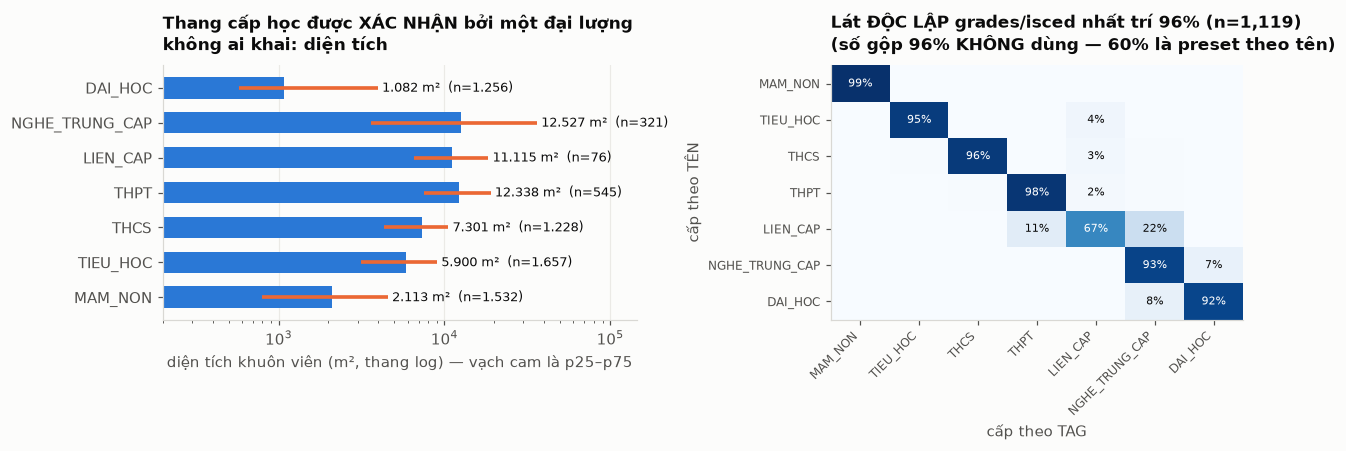

In [11]:
# TRỤC 3 — DIỆN TÍCH kiểm lại trục 1. Ràng buộc vật lý: số lớp × sĩ số × chuẩn m²/học sinh.
# Nếu thang cấp học là thật thì diện tích phải tăng đơn điệu theo nó — và đây là kiểm định
# ĐỘC LẬP với cả hai nguồn ở trên (diện tích do hình vẽ quyết định, không do ai khai).
# THỨ TỰ ƯU TIÊN — sửa sau khi ma trận nhầm lẫn chỉ ra một sai hệ thống:
# 25 trường ĐẠI HỌC mang `amenity=college` ("Trường Đại học Ngân hàng", "Học viện Chính trị
# Khu vực 4"). Ở VN, người map dùng `college` cho cả đại học lẫn cao đẳng — tag này KHÔNG
# phân biệt được hai bậc, còn tên thì phân biệt rõ. Nên chỉ tag CÓ CẤU TRÚC (`grades`,
# `isced:level`) mới được thắng tên; `amenity`/`education` là lớp đáy, xếp sau tên.
cap_tag_manh = th["grades"].map(cap_tu_grades).fillna(th["isced_level"].map(cap_tu_isced))
th["cap_tag_manh"] = cap_tag_manh
th["cap_chot"] = cap_tag_manh.fillna(th["cap_ten"].replace("KHAC", np.nan)).fillna(th["cap_tag"]).fillna("KHAC")
print(f"nguồn của `cap_chot`: tag có cấu trúc {cap_tag_manh.notna().sum():,}"
      f" · tên {int((cap_tag_manh.isna() & th['cap_ten'].ne('KHAC')).sum()):,}"
      f" · tag đáy {int((cap_tag_manh.isna() & th['cap_ten'].eq('KHAC') & th['cap_tag'].notna()).sum()):,}"
      f" · không xác định {int((cap_tag_manh.isna() & th['cap_ten'].eq('KHAC') & th['cap_tag'].isna()).sum()):,}")
_p = th[th["is_area"] & th["area_m2"].gt(0)]
bang_dt = _p.groupby("cap_chot").agg(
    n=("area_m2", "size"),
    dt_tv=("area_m2", "median"),
    dt_p25=("area_m2", lambda s: s.quantile(0.25)),
    dt_p75=("area_m2", lambda s: s.quantile(0.75)),
)
bang_dt = bang_dt.reindex([c for c in CAP_BAC if c in bang_dt.index])
print("diện tích khuôn viên theo cấp (chỉ polygon):")
print(bang_dt.round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
b = bang_dt.dropna(subset=["dt_tv"])
b = b[b.index != "KHAC"]
ax.barh(b.index, b["dt_tv"], color=BLUE, height=0.62)
ax.hlines(range(len(b)), b["dt_p25"], b["dt_p75"], color=ORANGE, linewidth=2.4, zorder=5)
for y, (v, n) in enumerate(zip(b["dt_tv"], b["n"])):
    ax.text(
        b["dt_p75"].iloc[y] * 1.06,
        y,
        f"{fmt(v)} m²  (n={fmt(n)})",
        va="center",
        fontsize=8.5,
        color=INK,
    )
ax.set_xscale("log")
ax.set_xlim(200, float(b["dt_p75"].max()) * 4)
ax.grid(axis="y", visible=False)
ax.set_xlabel("diện tích khuôn viên (m², thang log) — vạch cam là p25–p75")
ax.set_title(
    "Thang cấp học được XÁC NHẬN bởi một đại lượng\nkhông ai khai: diện tích",
    pad=10,
    loc="left",
    fontsize=11,
)

# VÁ THẨM ĐỊNH 2026-08-09: tiêu đề chỉ được trưng con số của lát ĐỘC LẬP (grades/isced).
# Số gộp lẫn 60% preset amenity — cell đối chứng phía trên đã tuyên bố "KHÔNG dùng số này".
_doc_lap = th.loc[doi_chung.index, "cap_tag_manh"].notna()
_nt_dl = float(khop[_doc_lap].mean()) if int(_doc_lap.sum()) else float("nan")
ax = axes[1]
share = mt.div(mt.sum(axis=1), axis=0)
im = ax.imshow(share.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(share.columns)))
ax.set_xticklabels(share.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(share.index)))
ax.set_yticklabels(share.index, fontsize=8)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        v = share.values[i, j]
        if v > 0.01:
            ax.text(
                j,
                i,
                f"{v:.0%}",
                ha="center",
                va="center",
                fontsize=7.5,
                color="#ffffff" if v > 0.5 else INK,
            )
ax.grid(visible=False)
ax.set_xlabel("cấp theo TAG")
ax.set_ylabel("cấp theo TÊN")
ax.set_title(
    f"Lát ĐỘC LẬP grades/isced nhất trí {_nt_dl:.0%} (n={int(_doc_lap.sum()):,})"
    f"\n(số gộp {khop.mean():.0%} KHÔNG dùng — 60% là preset theo tên)",
    pad=10,
    loc="left",
    fontsize=11,
)
fig.tight_layout()
plt.show()

### REVIEW — cấp học và con số precision đầu tiên có thật

*(Số trong mục này thuộc lần chạy 2026-08-09 — **sinh lại sau lần chạy tới**.)*

**Soi gì:** hai bản dựng cấp học (tên tiếng Việt vs `grades`/`isced:level`/`amenity`),
PHÂN RÃ theo nguồn gốc tag, ma trận nhầm lẫn, và một kiểm định thứ ba bằng diện tích.

**Tìm được:**
- **Số gộp (96,4%) không được dùng**: 60% tập đối chứng lấy `cap_tag` từ preset
  `amenity`/`education` — preset là thứ người map bấm SAU KHI đọc tên, tức tên khai lại
  lần thứ hai chứ không phải nhân chứng thứ hai. Bằng chứng phụ thuộc đo ngay trong cell
  trên: P(có `grades` | tên nói cấp) gấp ~25× P(có `grades` | tên KHÔNG nói cấp).
- Con số được phép trích dẫn: **nhất trí trên lát ĐỘC LẬP `grades`/`isced` ≈ 95,7%**,
  kèm Wilson 95% in ở cell trên.
- **Diện tích xác nhận thang cấp học** — nhân chứng thứ ba, độc lập thật (do hình vẽ
  quyết định, không do ai khai): trung vị tăng đơn điệu qua các cấp phổ thông. Lưu ý khi
  đọc bảng: đo trên MỌI dòng nên nhóm ĐH bị các dãy nhà trong khuôn viên kéo tụt trung vị
  — muốn thấy đúng phải nhìn sau khi lọc `container_uid` (bước 4).
- Chỗ **bất đồng** cho ra một danh sách soi tay ngắn, cắm cờ `cap_xung_dot`.

**Quyết định:** `cap_chot` ưu tiên tag CÓ CẤU TRÚC (`grades`/`isced`) hơn TÊN, và TÊN hơn
tag preset (`amenity`/`education`) — preset không được thắng tên vì nó sinh TỪ tên.
Dòng bất đồng vẫn giữ trong lớp, có cờ.

**Giới hạn:** tập đối chứng chỉ là phần **có cả hai nguồn**. Nhóm chỉ có một nguồn (hoặc
không nguồn nào) không được con số này bảo chứng — và đó vẫn là đa số.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

In [12]:
candidates = th.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []


# `co_bang_chung_truong` định nghĩa MỘT LẦN ở cell BẰNG CHỨNG phía trên — bản sao thứ hai
# ở đây từng là chỗ hai định nghĩa trôi khỏi nhau mà không ai biết.

def drop_rule(cond, rule, n=6, tha_truong=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_truong:
        tha = m & co_bang_chung_truong(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có tag giáo dục CỨNG → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_truong(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có tag giáo dục cứng:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 13,486 dòng


In [13]:
# LUẬT 1 — hạ tầng đường. Luật số 1 của SÁU lớp liên tiếp. Ở đây nó bắt các trạm buýt tên
# "Trường THPT Chu Văn An" — đúng bẫy "tên là mốc tham chiếu" của lớp nhà ở, lần thứ sáu.
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "tên có 'trường' mà dính luật này:",
    int((INFRA & remaining["name_norm"].str.contains(r"\btruong ", na=False)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

tên có 'trường' mà dính luật này: 1120

HA_TANG_DUONG: xoá 1,454  →  còn lại 12,032
  mẫu : ['477 Nguyễn Trãi - Học viện Khoa học Xã hội', 'Đại học Kiến Trúc - Trần Phú (Hà Đông)', 'Học viện công nghệ bưu chính viễn thông - Trần Phú (Hà Đông)', 'Trạm bus', 'Trạm bus', '212 Hoàng Quốc Việt - đối diện Học viện Chính trị Quốc gia Hồ Chí Minh']
  ⚠ 5 dòng có tag giáo dục cứng: ['Trạm bus', 'Trạm bus', 'Trung Tâm Đào Tạo Và Sát Hạch Lái Xe Cơ Giới Đường Bộ Cần Thơ', 'Trường Tiểu Học - Trung học cơ sở - Trung học phổ thông Ngô Thời Nhiệm']


In [14]:
# LUẬT 2 — CƠ QUAN QUẢN LÝ GIÁO DỤC, không phải trường. "Phòng Giáo dục và Đào tạo",
# "Sở GD&ĐT" là cơ quan hành chính — thuộc lớp HÀNH CHÍNH chạy sau. Quyết một lần tại đây.
CO_QUAN_GD = remaining["name_norm"].str.contains(
    r"^(?:so|phong|bo|cuc|vu|ban)\s.*(?:giao duc|dao tao)|\bgd\s?&?\s?dt\b|phong gd|so gd"
    r"|cong doan giao duc|hoi khuyen hoc",
    na=False,
)
# "Ban Đào tạo" của một trường đại học KHÔNG phải cơ quan quản lý nhà nước — nó khớp
# `^ban\s.*dao tao` y hệt "Ban Đào tạo Sở GD&ĐT". Phân biệt bằng TAG chứ không bằng tên:
# `office=university` là đơn vị TRONG trường.
CO_QUAN_GD = CO_QUAN_GD & ~remaining["office"].eq("university")
print()
drop_rule(CO_QUAN_GD, "CO_QUAN_QUAN_LY_GD")


CO_QUAN_QUAN_LY_GD: xoá 4  →  còn lại 12,028
  mẫu : ['Phòng giáo dục đào tạo Ninh Kiều', 'Phòng GD&ĐT huyện Cờ Đỏ', 'Sở Giáo dục và Đào tạo Thành phố Hồ Chí Minh', 'Phòng Giáo dục và Đào tạo quận Thanh Xuân']
  ⚠ 2 dòng có tag giáo dục cứng: ['Phòng giáo dục đào tạo Ninh Kiều', 'Phòng GD&ĐT huyện Cờ Đỏ']


In [15]:
# LUẬT 3 — họ tag thuộc LỚP KHÁC: căng tin, nhà sách, bãi đỗ, phòng khám trong trường được
# map thành POI riêng. `tha_truong` giữ lại dòng vừa mang tag trường vừa mang tag khác.
NGOAI_LOP = (
    remaining["amenity"].isin(
        [
            "restaurant",
            "cafe",
            "fast_food",
            "bar",
            "pub",
            "parking",
            "fuel",
            "bank",
            "atm",
            "pharmacy",
            "hospital",
            "clinic",
            "doctors",
            "dentist",
            "marketplace",
            "police",
            "fire_station",
            "post_office",
            "townhall",
            "courthouse",
            "place_of_worship",
            "toilets",
            "shelter",
            "bus_station",
            "library",
            "theatre",
            "cinema",
            # ── THIẾT BỊ ĐẶT NHỜ ĐỊA ĐIỂM (thẩm định 2026-08-09) ──
            # Vật thể là THIẾT BỊ, cái tên là ĐỊA ĐIỂM CHỦ: "TNGo - Bảo tàng Chiến thắng B52",
            # "TNGo - Học viện Ngoại giao", "TNGo - Vincom Phạm Ngọc Thạch". Chúng lọt vào lớp
            # qua nhánh TÊN, và vì là node trần không mang `highway`/`public_transport` nên luật
            # hạ tầng đường KHÔNG bắt được. Đây là bẫy "tên là mốc tham chiếu" ở dạng thuần nhất.
            # Đo 2026-08-09: 12 dòng rải ở 4 lớp. Ở quy mô toàn quốc xe đạp công cộng đang mở
            # rộng nhanh, nên đây là danh sách chặn theo TAG (không theo tên) để khỏi phải đuổi
            # theo từng thương hiệu.
            "bicycle_rental",
            "vending_machine",
            "parcel_locker",
        ]
    )
    | remaining["shop"].notna()
    | remaining["healthcare"].notna()
    | remaining["tourism"].notna()
    | remaining["leisure"].notna()
)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_truong=True)


  ⊙ 11 dòng có tag giáo dục CỨNG → GIỮ, cờ mixed_use: ['Nhà ăn UEL', 'Căn tin 3 Sao', 'XU Kafe', 'A19', 'Trung tâm Huấn luyện và Bồi dưỡng Nghiệp vụ Công an Tỉnh Bình Phước']
TAG_LOP_KHAC: xoá 63  →  còn lại 11,965
  mẫu : ['Thư viện Trường Đại học Nông Lâm', 'Trung Tâm Tiếng Anh Hội Việt Mỹ - VUS', 'Family Mart Ký Túc Xá Đại Học Quốc Giá', 'BoBaPop - Làng Đại Học', 'Red Bridge Restaurant and Cooking School', 'Căn tin bệnh viện Đại học Y dược']


In [16]:
# LUẬT 4 — TÊN RIÊNG "TRƯỜNG", không phải trường học. Bẫy tiếng Việt đắt nhất của lớp này:
# "Trường Sơn", "Trường Giang", "Trường Chinh" là TÊN RIÊNG rất phổ biến (dãy núi, dòng
# sông, tên người, tên đường). Nhánh B của bước 1 cố tình tuyển rộng; đây là chỗ trả về.
#
# Điều kiện: tên có "trường" nhưng KHÔNG có danh từ cấp học nào, VÀ không có tag giáo dục.
# BẪY ĐẮT NHẤT CỦA LUẬT NÀY, và nó không nằm ở tên riêng: bỏ dấu xong thì **"môi trường"
# chứa `\btruong\b`**. Cùng họ: "thị trường", "quảng trường", "nông trường", "công trường",
# "phi trường". Đo trên pool: 159 dòng khớp `\btruong\b` mà thật ra là danh từ ghép; trong
# 14 dòng luật này xoá thì 8 dòng — 57% — là do bẫy đó, gồm 7 Viện nghiên cứu môi trường.
# RE2 KHÔNG có lookbehind, nên không viết được `(?<!moi )truong`. Phải dựng mask riêng rồi trừ.
DANH_TU_GHEP_TRUONG = r"\b(?:moi|thi|quang|nong|cong|chien|phi|hien|thao|doanh|lam|ngu|dong) truong\b"
LUAT_GHEP = [
    Luat(
        ma="DANH_TU_GHEP_TRUONG",
        cot="name_norm",
        rx=DANH_TU_GHEP_TRUONG,
        khop=("vien moi truong va tai nguyen", "quang truong 2/9", "nong truong pham van coi"),
        truot=("truong tieu hoc kim dong", "truong son", "cong ty truong thanh"),
    )
]
kiem_luat(LUAT_GHEP, remaining)
_ghep = mask(remaining, LUAT_GHEP[0])
print(f"dòng khớp `\\btruong\\b` mà thật ra là DANH TỪ GHÉP: {int(_ghep.sum()):,} — miễn cho luật này")

# "Trường" còn đi với những DANH TỪ TRƯỜNG HỌC nằm ngoài thang cấp: quốc tế, song ngữ,
# quân sự, chính trị, nghiệp vụ, chuyên biệt, dạy lái xe. Chúng là trường thật, chỉ là cấp
# học không đọc được từ tên. Đo trên pool: 112 dòng.
DANH_TU_TRUONG_HOC = (
    r"\btruong (?:day lai xe|lai xe|quan su|nghiep vu|chinh tri|can bo|dan toc|chuyen biet"
    r"|quoc te|song ngu|nuoi day|thuc hanh|huan luyen|boi duong|nang khieu|chuyen)\b"
)
LUAT_TRUONG_HOC_KHAC = [
    Luat(
        ma="DANH_TU_TRUONG_HOC",
        cot="name_norm",
        rx=DANH_TU_TRUONG_HOC,
        khop=("truong day lai xe tien phat", "truong quoc te viet uc", "truong quan su tinh"),
        truot=("truong son", "vien moi truong va tai nguyen", "cong ty truong thanh"),
    )
]
kiem_luat(LUAT_TRUONG_HOC_KHAC, remaining)
_th_khac = mask(remaining, LUAT_TRUONG_HOC_KHAC[0])

TEN_RIENG_TRUONG = (
    remaining["name_norm"].str.contains(r"\btruong\b", na=False)
    & ~_ghep
    & ~_th_khac
    & remaining["cap_ten"].eq("KHAC")
    & ~co_bang_chung_truong(remaining)
)
print(f"tên có 'trường' mà không cấp học và không tag giáo dục: {int(TEN_RIENG_TRUONG.sum()):,}")
print()
drop_rule(TEN_RIENG_TRUONG, "TEN_RIENG_KHONG_PHAI_TRUONG", n=10)

✓ 1 luật qua fixture (dtype `str` = RE2, nơi `\b` chỉ biết ASCII)
dòng khớp `\btruong\b` mà thật ra là DANH TỪ GHÉP: 30 — miễn cho luật này
✓ 1 luật qua fixture (dtype `str` = RE2, nơi `\b` chỉ biết ASCII)
tên có 'trường' mà không cấp học và không tag giáo dục: 4

TEN_RIENG_KHONG_PHAI_TRUONG: xoá 4  →  còn lại 11,961
  mẫu : ['Trường Trinh sát, Bộ Quốc phòng', 'Nghĩa trang Trường Sĩ quan Lục quân 2', 'Trường Vinstar', 'Trường Vinstar']


In [17]:
# LUẬT 5 — tên nói thẳng đây là loại khác.
# `chua` là token KHÔNG ĐƯỢC đọc trên tên đã bỏ dấu. Đo trên pool 162.507: `\bchua \b`
# khớp 520 dòng, trong đó chỉ 386 là CHÙA — còn 110 là "phòng cháy CHỮA cháy" / "sửa
# CHỮA xe máy" và 22 là "sữa CHUA". Run 7 tỉnh may mà chưa oan (luật này chỉ xoá 3 dòng),
# nhưng ở SCOPE="vn" nó sẽ xoá "Đại học Phòng cháy Chữa cháy".
# Sửa gốc, không sửa dòng: token nào phân biệt được BẰNG DẤU thì đọc trên `name_dau`.
LUAT_LOAI_KHAC = [
    Luat(
        ma="LOAI_KHAC_khong_dau",
        cot="name_norm",
        rx=(
            r"\bbenh vien\b|\bphong kham\b|\bubnd\b|\buy ban nhan dan\b|\bcong an\b|\btoa an\b"
            r"|\bkho bac\b|\bbuu dien\b|\bngan hang\b|\bnha may\b|\bxi nghiep\b|\bkcn\b"
            r"|\bkhach san\b|\bnha nghi\b|\bcay xang\b|\btram xang\b|\bsieu thi\b"
            r"|\btrung tam thuong mai\b|\bbai do xe\b|\bben xe\b|\bchung cu\b|\bnha tho\b"
        ),
        khop=("benh vien cho ray", "nha tho lon ha noi", "sieu thi co.opmart"),
        truot=("truong tieu hoc kim dong", "truong mam non hoa sen"),
    ),
    # Token phụ thuộc DẤU phải đọc trên tên CÒN DẤU. Đo trên pool: `\bchua \b` trên tên đã
    # bỏ dấu khớp 520 dòng mà chỉ 386 là chùa — 110 là "phòng cháy CHỮA cháy" / "sửa CHỮA
    # xe máy", 22 là "sữa CHUA". Chưa gây oan ở 7 tỉnh nhưng sẽ xoá "Đại học Phòng cháy
    # Chữa cháy" ở SCOPE="vn". Fixture bên dưới là thứ chặn nó tái phát.
    Luat(
        ma="LOAI_KHAC_co_dau",
        cot="name_dau",
        rx=r"\bchùa\b",
        khop=("Chùa Trấn Quốc", "chùa bộc"),
        truot=("Sửa chữa xe máy Giang Nam", "Sữa chua nếp cẩm", "Phòng cháy Chữa cháy Quận 1"),
    ),
]
kiem_luat(LUAT_LOAI_KHAC, remaining)
TEN_LOAI_KHAC = np.logical_or.reduce([mask(remaining, l).values for l in LUAT_LOAI_KHAC])
TEN_LOAI_KHAC = pd.Series(TEN_LOAI_KHAC, index=remaining.index) & ~co_bang_chung_truong(remaining)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")

✓ 2 luật qua fixture (dtype `str` = RE2, nơi `\b` chỉ biết ASCII)

TEN_LOAI_KHAC: xoá 4  →  còn lại 11,957
  mẫu : ['Trường Đại học Tài chính - Ngân hàng Hà Nội', 'Bệnh viện Thú y', 'Bệnh Viện Đại Học Y Dược - Đại Học Y Dược', 'Phòng khám Đa khoa Đại học Phenikaa Hoàng Ngân']


In [18]:
# LUẬT 6 — MỐC THAM CHIẾU.
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 11,957
  mẫu : []


In [19]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

LUAT_CO_Y = {"CO_QUAN_QUAN_LY_GD", "TAG_LOP_KHAC"}
conflict = removed[co_bang_chung_truong(removed)]
print(f"POI có tag giáo dục CỨNG nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(cf_ngoai_y[["name", "amenity", "building", "grades", "drop_reason"]].head(25).to_string())
# VÁ THẨM ĐỊNH 2026-08-09: 30 từng là hằng đặt tay. Đầu vào lớp này còn đổi (vá lớp
# thamquan thả ~155 trường xuống đây), nên ngưỡng phải co giãn theo cỡ tập tuyển:
# 0,3% số ứng viên, SÀN 30 — không bao giờ chặt hơn mức đã cân nhắc bằng tay.
NGUONG_NGOAI_Y = max(30, round(0.003 * len(candidates)))
assert len(cf_ngoai_y) <= NGUONG_NGOAI_Y, (
    f"{len(cf_ngoai_y)} dòng trường bị luật NGOÀI Ý xoá (ngưỡng {NGUONG_NGOAI_Y})"
)

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có cấp học rõ ràng mà vẫn bị xoá ==")
risky = removed[removed["cap_ten"].ne("KHAC")]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có tag giáo dục CỨNG nhưng bị xoá: 7 — phân theo luật:
drop_reason
HA_TANG_DUONG         5
CO_QUAN_QUAN_LY_GD    2

── do LUẬT NGOÀI Ý (phải nhỏ): 5 ──
                                                                         name         amenity building grades    drop_reason
344                                                                  Trạm bus          school      NaN    NaN  HA_TANG_DUONG
358                                                                  Trạm bus          school      NaN    NaN  HA_TANG_DUONG
3815            Trung Tâm Đào Tạo Và Sát Hạch Lái Xe Cơ Giới Đường Bộ Cần Thơ  driving_school      NaN    NaN  HA_TANG_DUONG
8803   Trường Tiểu Học - Trung học cơ sở - Trung học phổ thông Ngô Thời Nhiệm          school      NaN    NaN  HA_TANG_DUONG
19229                                                                     NaN          school      NaN    NaN  HA_TANG_DUONG

== tổng hợp theo luật ==
drop_reason
HA_TANG_DUONG                  1454
TAG_LOP_KHAC        

In [20]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print("tỷ lệ sống sót theo nhánh tuyển:")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:20s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:20s} —")

giữ : 11,957 → poi_truonghoc_7tinh_b3.parquet
xoá : 1,529 → poi_truonghoc_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển:
  A tag giáo dục       11,874/11,881 = 100%
  B tên                6,370/7,889  = 81%
  C vòng đời               2/2      = 100%
  D .edu.vn              520/526    = 99%


## Bước 4 — ĐO: đếm TRƯỜNG, không đếm dòng

In [21]:
# [DATA] sinh cột: container_uid, vai_tro, fragment_group
# Bệnh nặng nhất của lớp này: một ngôi trường được vẽ HAI lần — một polygon khuôn viên
# (`amenity=school`) và nhiều polygon dãy nhà (`building=school`) bên trong nó.
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
clean["vai_tro"] = np.where(
    clean["container_uid"].notna(), "TOA_TRONG_KHUON_VIEN", "KHUON_VIEN_HOAC_DIEM"
)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"dòng nằm TRONG một polygon giáo dục khác: {n_ct:,}"
    f"  → đếm TRƯỜNG: {n_row - n_ct:,} thay vì {n_row:,} ({n_ct / n_row:.1%} đếm đôi)"
)
print(
    f"trong đó {int((clean['container_uid'].notna() & clean['name'].isna()).sum()):,} dòng VÔ DANH"
    " — gần như chắc chắn là dãy nhà trong khuôn viên"
)
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)
print("\n5 khuôn viên chứa nhiều dãy nhà nhất:")
for u, k in clean["container_uid"].value_counts().head(5).items():
    r = clean.loc[clean["uid"].eq(u)].iloc[0]
    print(
        f"  {k:3d} POI con — {r['name'] or '(vô danh)'} | {r['cap_chot']} | {r['area_m2']:,.0f} m²"
    )

dòng nằm TRONG một polygon giáo dục khác: 5,357  → đếm TRƯỜNG: 6,600 thay vì 11,957 (44.8% đếm đôi)
trong đó 3,957 dòng VÔ DANH — gần như chắc chắn là dãy nhà trong khuôn viên
nhóm trùng tên cùng ô H3: 155 nhóm, 324 dòng

5 khuôn viên chứa nhiều dãy nhà nhất:
   45 POI con — Đại học Bách khoa Hà Nội | DAI_HOC | 264,452 m²
   44 POI con — Trường Cao đẳng Nghề số 8 | NGHE_TRUNG_CAP | 195,209 m²
   42 POI con — Học viện Nông nghiệp Việt Nam | DAI_HOC | 1,870,483 m²
   38 POI con — Đại học Cần Thơ (khu II) | DAI_HOC | 717,980 m²
   22 POI con — Học viện Báo chí và Tuyên truyền | DAI_HOC | 32,919 m²


In [22]:
# [DATA] sinh cột: hang_th, cap_hieu_luc, cap_nguon
#
# BỆNH CŨ: `hang` khởi tạo "PHO_THONG" cho MỌI dòng rồi mới override. Dòng nào không rơi
# vào luật nào thì mắc kẹt ở PHO_THONG mà không ai bảo chứng — đo được 1.215/5.189 dòng
# PHO_THONG có `cap_chot=KHAC`, gồm "TT Anh Ngữ Atlas", "Viện Khoa học Thống kê", "Khu F",
# "Dãy C". Đó là 23% thổi phồng, và README dặn đọc đúng cột này.
#
# NGUYÊN TẮC MỚI: mặc định là KHÔNG BIẾT. Mỗi hạng phải có đường dẫn bằng chứng, và
# `cap_nguon` ghi lại bằng chứng đó là gì — không có xuất xứ thì không có nhãn.
nn_c = clean["name_norm"]

# Toà nhà trong khuôn viên kế thừa cấp của khuôn viên chứa nó. Quan hệ chứa đã được dựng
# và kiểm ở cell trên, nên đây là suy diễn có bằng chứng KHÔNG GIAN, không phải mặc định.
# Cố ý KHÔNG ghi đè `cap_chot`: giá trị kế thừa mà trộn vào cột đo thì phép đối chứng
# chéo ở bước 2 mất tính trong sạch. Nó đi vào cột riêng.
_cap_theo_uid = clean.drop_duplicates("uid").set_index("uid")["cap_chot"]
_ke_thua = clean["container_uid"].map(_cap_theo_uid)
_ke_thua = _ke_thua.where(_ke_thua.ne("KHAC"))
clean["cap_hieu_luc"] = clean["cap_chot"].where(clean["cap_chot"].ne("KHAC")).fillna(_ke_thua).fillna("KHAC")

nguon = pd.Series("khong_ro", index=clean.index)
nguon[clean["cap_tag"].notna() & clean["cap_chot"].ne("KHAC")] = "tag_day"
nguon[clean["cap_ten"].ne("KHAC")] = "ten"
nguon[clean["cap_tag_manh"].notna()] = "tag_co_cau_truc"
nguon[clean["cap_chot"].eq("KHAC") & _ke_thua.notna()] = "ke_thua_khuon_vien"
clean["cap_nguon"] = nguon

CAP_PHO_THONG = {"TIEU_HOC", "THCS", "THPT", "LIEN_CAP"}
# Trung tâm đào tạo: mở rộng sau khi đo — nhánh cũ đòi cụm liền "trung tam ngoai ngu" nên
# trượt hết "TT ngoại ngữ AMA" (viết tắt) và "Anh ngữ Gia Việt" (không có chữ "trung tâm").
# Thêm TT GDNN-GDTX viết ĐẦY ĐỦ: 81 dòng, bước 1 đã tuyển mà thang cấp chưa hề đọc tới.
TTDT_RX = (
    r"\btrung tam (?:ngoai ngu|anh ngu|tin hoc|day nghe|boi duong|luyen thi|du hoc)\b"
    r"|\btt (?:ngoai ngu|anh ngu|tin hoc|day nghe|boi duong|luyen thi|du hoc)\b"
    r"|\bluyen thi\b|\bltdh\b|\banh ngu\b|\bngoai ngu\b|\banh van\b|\btu van du hoc\b"
    r"|\bielts\b|\btoeic\b|\btoefl\b"
    r"|\bgiao duc thuong xuyen\b|\bgiao duc nghe nghiep\b|\bsat hach lai xe\b"
)

hang = pd.Series("KHONG_XAC_DINH", index=clean.index)
hang[clean["cap_hieu_luc"].isin(CAP_PHO_THONG)] = "PHO_THONG"
hang[clean["cap_hieu_luc"].eq("MAM_NON")] = "MAM_NON"
hang[clean["cap_hieu_luc"].eq("DAI_HOC")] = "DAI_HOC_HOC_VIEN"
hang[clean["cap_hieu_luc"].eq("NGHE_TRUNG_CAP")] = "NGHE_CAO_DANG"
# CÓ bằng chứng là cơ sở giáo dục nhưng KHÔNG suy ra được bậc → hạng riêng, không đoán bừa.
hang[clean["cap_hieu_luc"].eq("KHAC") & co_bang_chung_truong(clean)] = "TRUONG_CHUA_RO_CAP"
hang[
    clean["amenity"].isin(["language_school", "music_school", "driving_school", "prep_school"])
    | nn_c.str.contains(TTDT_RX, na=False)
] = "TRUNG_TAM_DAO_TAO"
hang[clean["amenity"].eq("research_institute")] = "VIEN_NGHIEN_CUU"
clean["hang_th"] = hang

print(clean["hang_th"].value_counts().to_string())
print()
print("xuất xứ của cấp học (cột `cap_nguon`):")
print(clean["cap_nguon"].value_counts().to_string())
print()
# CỔNG: không hạng nào được chứa dòng vô bảo chứng, trừ ba hạng ĐỊNH NGHĨA là chưa rõ cấp.
HANG_CHUA_RO = {"KHONG_XAC_DINH", "TRUONG_CHUA_RO_CAP", "TRUNG_TAM_DAO_TAO", "VIEN_NGHIEN_CUU"}
_vo_bao_chung = clean[
    clean["cap_hieu_luc"].eq("KHAC") & ~clean["hang_th"].isin(HANG_CHUA_RO)
]
assert len(_vo_bao_chung) == 0, f"{len(_vo_bao_chung)} dòng mang nhãn cấp mà không có bảo chứng"
print(f"✓ 0 dòng mang nhãn bậc học mà không có bảo chứng (trước khi sửa: 1.215)")
print()
print(pd.crosstab(clean["hang_th"], clean["vai_tro"]).to_string())
print(f"\ncấp chốt: {clean['cap_chot'].value_counts().to_dict()}")
print(f"cờ xung đột hai nguồn: {int(clean['cap_xung_dot'].sum()):,}")


hang_th
PHO_THONG             6759
MAM_NON               1861
DAI_HOC_HOC_VIEN      1466
TRUONG_CHUA_RO_CAP     768
NGHE_CAO_DANG          632
TRUNG_TAM_DAO_TAO      347
VIEN_NGHIEN_CUU        100
KHONG_XAC_DINH          24

xuất xứ của cấp học (cột `cap_nguon`):
cap_nguon
ten                   4847
ke_thua_khuon_vien    3256
tag_day               1541
tag_co_cau_truc       1157
khong_ro              1156

✓ 0 dòng mang nhãn bậc học mà không có bảo chứng (trước khi sửa: 1.215)

vai_tro             KHUON_VIEN_HOAC_DIEM  TOA_TRONG_KHUON_VIEN
hang_th                                                       
DAI_HOC_HOC_VIEN                     350                  1116
KHONG_XAC_DINH                        23                     1
MAM_NON                             1302                   559
NGHE_CAO_DANG                        320                   312
PHO_THONG                           3665                  3094
TRUNG_TAM_DAO_TAO                    312                    35
TRUONG_CHUA_R

## Bước 5 — FINAL và bộ CÒN LẠI

In [23]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
# `fragment_group` (cùng tên + cùng ô H3) đã được TÍNH ở cell trên nhưng chưa từng được
# DÙNG khi đếm — một ngôi trường vẽ thành 2 polygon rời vẫn bị đếm 2 lần.
_top = final[final["container_uid"].isna()]
_du = int(_top["fragment_group"].notna().sum() - _top["fragment_group"].nunique())
print(f"top-level (lọc container_uid) : {len(_top):,}")
print(f"trừ mảnh vụn trùng tên+ô H3   : {_du:,}")
print(f"số CƠ SỞ giáo dục             : {len(_top) - _du:,}")
print()
print(
    final.groupby("hang_th")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 11,957 dòng, 79 cột → poi_truonghoc_7tinh_final.parquet
top-level (lọc container_uid) : 6,600
trừ mảnh vụn trùng tên+ô H3   : 56
số CƠ SỞ giáo dục             : 6,544

hang_th                DAI_HOC_HOC_VIEN  KHONG_XAC_DINH  MAM_NON  NGHE_CAO_DANG  PHO_THONG  TRUNG_TAM_DAO_TAO  TRUONG_CHUA_RO_CAP  VIEN_NGHIEN_CUU
province_name                                                                                                                                     
Thành phố Cần Thơ                    67               2      109             53        314                 64                  39                0
Thành phố Hà Nội                    787               9      967            233       2815                107                 294               79
Thành phố Hải Phòng                  38               1       82             35        253                 16                  38                2
Thành phố Hồ Chí Minh               381               9      517            154       2171

In [24]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in ["chungcu", "luutru", "thuongmai", "giaitri", "thamquan"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp Y TẾ trong bộ còn lại:")
_am = _td.map(lambda t: t.get("amenity"))
print(
    "  amenity:",
    _am[_am.isin(["hospital", "clinic", "doctors", "dentist", "pharmacy"])]
    .value_counts()
    .to_dict(),
)
print("  healthcare=*:", _td.map(lambda t: t.get("healthcare")).notna().sum())

bộ vào    : 162,669
đã bóc ra : 11,957
CÒN LẠI   : 150,712  → poi_extended_7tinh_con_lai_sau_truonghoc.parquet


✓ 1,529 dòng bị 5 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai
✓ không đếm đôi với lớp giaitri
✓ không đếm đôi với lớp thamquan



nguyên liệu lớp Y TẾ trong bộ còn lại:
  amenity: {'pharmacy': 1341, 'hospital': 692, 'clinic': 523, 'dentist': 198, 'doctors': 137}
  healthcare=*: 1977


### Cổng recall 3 — đầu dò độc lập có quyền đỏ

In [25]:
# ══ CỔNG RECALL 3 — và một điều phải nói thẳng về giới hạn của nó ══
#
# Hai cổng recall cũ KHÔNG THỂ đỏ, đó là lỗi phương pháp chứ không phải may:
#   · Cổng 1: cả 14 phép thử đều là TẬP CON của chính luật tuyển → tự chấm bài mình.
#   · Cổng 2: đầu dò cứng `school:*`/`capacity:students` khớp 0 dòng trên TOÀN pool 162k —
#     đầu dò không chạm được dữ liệu thì nó không kiểm được gì.
#
# NGHỊCH LÝ CỦA ĐẦU DÒ: tín hiệu đủ mạnh để làm đầu dò thì cũng đủ mạnh để làm luật tuyển,
# và một khi đã tuyển theo nó thì nó không còn kiểm được mình nữa. Nên đầu dò có VÒNG ĐỜI:
#   ĐANG SỐNG → báo đỏ → ta sửa luật theo nó → nó TIÊU, và từ đó chỉ còn là test hồi quy.
# Cổng này ghi rõ đầu dò nào đã tiêu, thay vì giả vờ mình vẫn còn độc lập.
_td_cl = con_lai["tags"].map(parse_tags)
# Dòng bị luật bước 3 xoá CÓ CHỦ Ý (nhường lớp hành chính / y tế) vẫn nằm trong `con_lai`.
# Chúng không phải lỗ recall, nên phải tách ra trước khi kết luận.
_chua_tuyen = ~con_lai["uid"].isin(set(th["uid"]))
_da_xoa = con_lai["uid"].map(removed.set_index("uid")["drop_reason"])

# ── ĐÃ TIÊU (2026-08-09) — nay là TEST HỒI QUY, không còn là phép đo recall ──
A = _td_cl.map(
    lambda t: "edu.vn"
    in " ".join(str(t.get(k, "")) for k in ("website", "contact:website", "url",
                                            "contact:url", "email", "contact:email")).lower()
)
B = _td_cl.map(lambda t: str(t.get("office", "")).lower() in OFFICE_GD)
DA_TIEU = {
    "A · tên miền .edu.vn → đã thành NHÁNH TUYỂN D": A,
    "B · office ∈ giáo dục → đã vào TH_TAG": B,
}
print("── ĐẦU DÒ ĐÃ TIÊU (test hồi quy, phải = 0 trên nhóm CHƯA TỪNG TUYỂN) ──")
_thung = 0
for ten, m in DA_TIEU.items():
    con = int((m & _chua_tuyen).sum())
    nhuong = _da_xoa[m & ~_chua_tuyen].value_counts().to_dict()
    _thung += con
    print(f"  {'✗' if con else '✓'} {ten:52s} sót {con:3d} | nhường lớp khác: {nhuong}")
    if con:
        print("     ", con_lai.loc[m & _chua_tuyen, "name"].dropna().head(8).tolist())

# ── CÒN SỐNG — KHÔNG-GIAN-ÂM bằng HÌNH THÁI (mượn của eda_chungcu) ──
# Đây là đầu dò DUY NHẤT còn độc lập, và nó không thể trở thành luật tuyển: một mình nó
# không có precision (đa số là trạm biến áp). Vai trò của nó là chỉ ra ta đang MÙ ở đâu.
_q = final.loc[final["container_uid"].isna() & final["is_area"] & final["area_m2"].gt(0), "area_m2"]
_lo, _hi = _q.quantile(0.25), _q.quantile(0.90)
_TAG_CN = ["amenity", "shop", "office", "leisure", "tourism", "healthcare", "landuse", "building",
           "man_made", "historic", "military", "craft", "place", "railway", "highway", "aeroway",
           "public_transport", "power", "natural", "waterway", "barrier"]
C_ = con_lai["is_area"] & con_lai["area_m2"].between(_lo, _hi) & con_lai[_TAG_CN].isna().all(axis=1)
print(f"\n── ĐẦU DÒ CÒN SỐNG (mềm — soi, không chặn) ──")
print(f"  ⊙ C · polygon cỡ trường ({_lo:,.0f}–{_hi:,.0f} m²), KHÔNG tag chức năng nào: {int(C_.sum()):,}")
_c = con_lai[C_ & _chua_tuyen]
if len(_c):
    print(f"     20 mẫu (seed 42) — đây là vùng unknown-unknown của lớp này:")
    print(_c[["name", "area_m2", "province_name"]].sample(min(20, len(_c)), random_state=42).to_string(index=False))

assert _thung == 0, f"RECALL THỦNG: {_thung} dòng — cơ sở giáo dục chưa từng được tuyển"
print("\n✓ test hồi quy đạt. LƯU Ý: recall của lớp này hiện chỉ còn MỘT đầu dò mềm canh giữ;")
print("  muốn có đầu dò CỨNG mới thì phải lấy tín hiệu từ nguồn NGOÀI OSM.")


── ĐẦU DÒ ĐÃ TIÊU (test hồi quy, phải = 0 trên nhóm CHƯA TỪNG TUYỂN) ──
  ✓ A · tên miền .edu.vn → đã thành NHÁNH TUYỂN D        sót   0 | nhường lớp khác: {'TAG_LOP_KHAC': 3, 'CO_QUAN_QUAN_LY_GD': 2, 'TEN_LOAI_KHAC': 1}
  ✓ B · office ∈ giáo dục → đã vào TH_TAG                sót   0 | nhường lớp khác: {'CO_QUAN_QUAN_LY_GD': 2}

── ĐẦU DÒ CÒN SỐNG (mềm — soi, không chặn) ──
  ⊙ C · polygon cỡ trường (2,977–19,450 m²), KHÔNG tag chức năng nào: 22
     20 mẫu (seed 42) — đây là vùng unknown-unknown của lớp này:
                                        name      area_m2         province_name
                                         NaN  3100.425617      Thành phố Hà Nội
                               Tê giác trắng  2990.578727   Thành phố Hải Phòng
                                         NaN  8886.781529 Thành phố Hồ Chí Minh
                                         NaN  4283.405898 Thành phố Hồ Chí Minh
                                    Nhà chim  3313.123620   Thành phố Hải Phòng
    

### Kiểm toán recall — con số, không chỉ cổng xanh

In [26]:
# ══ KIỂM TOÁN RECALL — một CON SỐ, không chỉ một cổng xanh ══
#
# Cổng đạt chỉ nói "đầu dò tôi có không kêu". Nó không nói recall bằng bao nhiêu.
# Cách đo ở đây: SÀNG RỘNG trên nhóm CHƯA TỪNG TUYỂN bằng mọi hình vị liên quan giáo dục
# (rộng hơn hẳn luật tuyển, precision thấp là cố ý), rồi đọc tay từng tầng.
#
# Bắt–bắt lại (Lincoln-Petersen) đã thử và BỎ: bốn đầu dò cho N̂ mâu thuẫn nhau từ 4,8%
# đến 449% vì chúng bắt những quần thể khác nhau, không phải cùng một quần thể "trường".
_chua = poi[~poi["uid"].isin(set(th["uid"]))]
_nn = _chua["name_norm"].fillna("")
SANG = {
    "khoa / bộ môn / giảng đường": r"\bkhoa\b|\bbo mon\b|\bgiang duong\b",
    "giáo dục / đào tạo / bồi dưỡng": r"\bgiao duc\b|\bdao tao\b|\bhuan luyen\b|\bboi duong\b",
    "học / học sinh / sinh viên": r"\bhoc\b|\bhoc sinh\b|\bsinh vien\b|\bhoc tap\b",
    "lớp / nhà trẻ / trẻ em": r"\blop \b|\bnha tre\b|\btre em\b|\bmau giao\b",
    "ký túc xá / nội trú": r"\bky tuc xa\b|\bktx\b|\bnoi tru\b|\bban tru\b",
    "'trường' mọi dạng": r"\btruong\b",
    "tiếng anh / ngoại ngữ": r"\banh ngu\b|\bngoai ngu\b|\btieng anh\b|\benglish\b|\bielts\b",
    "edu / academy / campus": r"\bedu\b|\bacademy\b|\binstitute\b|\bcampus\b",
    "viện / trung tâm": r"\bvien\b|\btrung tam\b",
}
_tong = pd.Series(False, index=_chua.index)
print(f"CHƯA TỪNG TUYỂN: {len(_chua):,} dòng ({int(_chua['name'].notna().sum()):,} có tên)\n")
for lab, rx in SANG.items():
    m = _nn.str.contains(rx, na=False)
    _tong |= m
    print(f"  {lab:32s} {int(m.sum()):6,}")
print(f"\nSÀNG RỘNG bắt: {int(_tong.sum()):,} dòng — đây là toàn bộ vùng phải đọc tay.")

# Phán quyết ĐỌC TAY bên dưới ghim vào snapshot sàng lúc đọc (2026-08-09). Cảnh báo
# MỀM chứ không assert: trôi nhỏ không làm sai cả bảng, nhưng trôi >5% thì SOT /
# KHONG_PHAI_SOT / RECALL là số CŨ, phải đọc lại tay trước khi trích dẫn.
_SANG_SNAPSHOT = 3216
if abs(int(_tong.sum()) - _SANG_SNAPSHOT) > 0.05 * _SANG_SNAPSHOT:
    print(f"\n⚠ sàng = {int(_tong.sum()):,} lệch >5% so với snapshot {_SANG_SNAPSHOT:,}"
          " lúc đọc tay — các con số SOT/KHONG_PHAI_SOT/RECALL bên dưới cần đọc lại.")

# ── Phán quyết ĐỌC TAY 2026-08-09 (đọc trọn từng tầng nhỏ, mẫu 45 ở tầng 'trường') ──
# Con số là SỐ DÒNG CÒN SÓT ước lượng, sau khi đã trừ phần cố ý nhường lớp khác.
SOT = {
    "'trường' + tên riêng/ngành ('Trường Cơ khí Hà Nội', 'Trường Hải Quân',"
    " 'Trường Ernst Thälmann')": 36,
    "trung tâm mang tên thương hiệu tiếng Anh (British Council, IvyPrep, ILA)": 9,
}
KHONG_PHAI_SOT = {
    "Sở / Phòng / Bộ GD&ĐT → lớp HÀNH CHÍNH": 41,
    "bệnh viện / phòng khám trường y → lớp Y TẾ": 6,
    "nhà xuất bản / nhà sách / công ty thiết bị giáo dục → không phải trường": 9,
    "ký túc xá → lớp lưu trú": 30,
    "trung tâm nuôi dưỡng người già / tâm thần → BẢO TRỢ XÃ HỘI": 9,
}
print("\n── đọc tay: cái gì còn sót, cái gì cố ý nhường ──")
for k, v in SOT.items():
    print(f"  ✗ SÓT   {v:3d}  {k}")
for k, v in KHONG_PHAI_SOT.items():
    print(f"  ✓ nhường {v:3d}  {k}")

_sot = sum(SOT.values())
_bat = len(th)
print(f"\n── ƯỚC LƯỢNG RECALL ──")
print(f"  bắt được          : {_bat:,}")
print(f"  còn sót (đọc tay) : {_sot:,}")
print(f"  RECALL ≈ {_bat / (_bat + _sot):.2%}  trên nhóm trường CÓ tín hiệu (tên · tag · .edu.vn)")
print()
print("  Kiểm chéo: 80 mẫu ngẫu nhiên NGOÀI sàng (61.216 dòng có tên) → 0/80 là cơ sở giáo dục;")
print("  sàng không bỏ sót cả một LOẠI nào, chỉ bỏ sót lẻ trong tầng 'trường'.")
print()
print("  GIỚI HẠN KHÔNG VƯỢT ĐƯỢC: trường mà tên là tên riêng thuần ('Trường Nam Sài Gòn'),")
print("  không tag, không website thì KHÔNG có tín hiệu nào trong OSM để phát hiện — và")
print("  không phân biệt được với 'Trường Sơn', 'Trường Chinh'. Đầu dò hình thái quét vùng")
print("  đó được 22 ứng viên và không có trường nào. Muốn hơn phải có nguồn NGOÀI OSM.")


CHƯA TỪNG TUYỂN: 149,183 dòng (64,493 có tên)

  khoa / bộ môn / giảng đường         565
  giáo dục / đào tạo / bồi dưỡng       56
  học / học sinh / sinh viên          243
  lớp / nhà trẻ / trẻ em               45
  ký túc xá / nội trú                  30
  'trường' mọi dạng                   517
  tiếng anh / ngoại ngữ                10


  edu / academy / campus               15
  viện / trung tâm                  2,166

SÀNG RỘNG bắt: 3,216 dòng — đây là toàn bộ vùng phải đọc tay.

── đọc tay: cái gì còn sót, cái gì cố ý nhường ──
  ✗ SÓT    36  'trường' + tên riêng/ngành ('Trường Cơ khí Hà Nội', 'Trường Hải Quân', 'Trường Ernst Thälmann')
  ✗ SÓT     9  trung tâm mang tên thương hiệu tiếng Anh (British Council, IvyPrep, ILA)
  ✓ nhường  41  Sở / Phòng / Bộ GD&ĐT → lớp HÀNH CHÍNH
  ✓ nhường   6  bệnh viện / phòng khám trường y → lớp Y TẾ
  ✓ nhường   9  nhà xuất bản / nhà sách / công ty thiết bị giáo dục → không phải trường
  ✓ nhường  30  ký túc xá → lớp lưu trú
  ✓ nhường   9  trung tâm nuôi dưỡng người già / tâm thần → BẢO TRỢ XÃ HỘI

── ƯỚC LƯỢNG RECALL ──
  bắt được          : 13,486
  còn sót (đọc tay) : 45
  RECALL ≈ 99.67%  trên nhóm trường CÓ tín hiệu (tên · tag · .edu.vn)

  Kiểm chéo: 80 mẫu ngẫu nhiên NGOÀI sàng (61.216 dòng có tên) → 0/80 là cơ sở giáo dục;
  sàng không bỏ sót cả một LOẠI nào, chỉ bỏ sót 

### Precision đo được + hợp đồng đầu ra

In [27]:
# ══ PRECISION đo bằng MẪU, và HỢP ĐỒNG ĐẦU RA ══
def wilson(k, n, z=1.96):
    if not n:
        return (float("nan"), float("nan"))
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h


# ── 1. HỢP ĐỒNG: những bất biến mà bất kỳ lần chạy nào cũng phải giữ ──
HANG_HOP_LE = {"PHO_THONG", "MAM_NON", "DAI_HOC_HOC_VIEN", "NGHE_CAO_DANG",
               "TRUNG_TAM_DAO_TAO", "TRUONG_CHUA_RO_CAP", "VIEN_NGHIEN_CUU", "KHONG_XAC_DINH"}
HANG_CHUA_RO = {"KHONG_XAC_DINH", "TRUONG_CHUA_RO_CAP", "TRUNG_TAM_DAO_TAO", "VIEN_NGHIEN_CUU"}
NGUON_HOP_LE = {"tag_co_cau_truc", "ten", "tag_day", "ke_thua_khuon_vien", "khong_ro"}

HD = {
    "uid duy nhất": final["uid"].is_unique,
    "hang_th nằm trong từ vựng": set(final["hang_th"]) <= HANG_HOP_LE,
    "cap_nguon nằm trong từ vựng": set(final["cap_nguon"]) <= NGUON_HOP_LE,
    "không nhãn bậc học nào thiếu bảo chứng":
        not len(final[final["cap_hieu_luc"].eq("KHAC") & ~final["hang_th"].isin(HANG_CHUA_RO)]),
    "mọi container_uid tồn tại trong final":
        final["container_uid"].dropna().isin(final["uid"]).all(),
    "cap_chot KHÔNG bị giá trị kế thừa làm bẩn":
        (final["cap_nguon"].eq("ke_thua_khuon_vien") <= final["cap_chot"].eq("KHAC")).all(),
    "final ∪ bị_xoá = b1, và rời nhau":
        set(final["uid"]) | set(removed["uid"]) == set(th["uid"])
        and not (set(final["uid"]) & set(removed["uid"])),
}
for k, v in HD.items():
    print(f"  {'✓' if v else '✗'} {k}")
assert all(HD.values()), "hợp đồng đầu ra bị vi phạm"

# ── 2. PRECISION theo tầng, có khoảng tin cậy ──
# Đếm CƠ SỞ, nên chỉ lấy mẫu ở tầng top-level: dãy nhà trong khuôn viên không phải cơ sở.
print("\n── mẫu kiểm precision (top-level, seed 42) — soi tay rồi ghi lại số vào bảng dưới ──")
_top = final[final["container_uid"].isna() & final["name"].notna()]
for h in sorted(_top["hang_th"].unique()):
    s = _top[_top["hang_th"].eq(h)]
    print(f"\n  ▸ {h}  (n={len(s):,})")
    print(s[["name", "cap_hieu_luc", "cap_nguon", "amenity", "building"]]
          .sample(min(10, len(s)), random_state=42).to_string(index=False))

# Kết quả soi tay 2026-08-09, 20 mẫu/hạng trên tầng top-level. Ghim theo snapshot
# final lúc soi; cảnh báo MỀM nếu lần chạy sau làm final trôi >5% — khi đó DA_SOI
# là số CŨ và bảng precision phải soi lại (mẫu vẫn seed 42 để tái lập).
_FINAL_SNAPSHOT = 11957
if abs(len(final) - _FINAL_SNAPSHOT) > 0.05 * _FINAL_SNAPSHOT:
    print(f"\n⚠ final = {len(final):,} lệch >5% so với snapshot {_FINAL_SNAPSHOT:,}"
          " lúc soi tay — DA_SOI bên dưới là số CŨ, cần soi lại 20 mẫu/hạng.")
DA_SOI = {"PHO_THONG": (20, 20), "MAM_NON": (20, 20), "DAI_HOC_HOC_VIEN": (20, 20),
          "VIEN_NGHIEN_CUU": (20, 20), "TRUNG_TAM_DAO_TAO": (20, 20),
          "NGHE_CAO_DANG": (18, 20), "TRUONG_CHUA_RO_CAP": (17, 20)}
print("\n── precision đã đo (mẫu tay, Wilson 95%) ──")
_tk, _tn = 0, 0
for h, (k, n) in DA_SOI.items():
    lo, hi = wilson(k, n)
    _tk += k
    _tn += n
    print(f"  {h:20s} {k:2d}/{n:2d} = {k / n:5.0%}   [{lo:.0%} – {hi:.0%}]")
_lo, _hi = wilson(_tk, _tn)
print(f"  {'GỘP':20s} {_tk:2d}/{_tn:2d} = {_tk / _tn:5.1%}   [{_lo:.1%} – {_hi:.1%}]")
print("\n  Hai hạng dưới 100% là lỗi NGUỒN chứ không phải lỗi luật:")
print("   · NGHE_CAO_DANG  — 'Brighton College' (trường quốc tế K-12) mang amenity=college")
print("   · TRUONG_CHUA_RO_CAP — 'trạm kiểm soát tàu hoả' mang building=school")


  ✓ uid duy nhất
  ✓ hang_th nằm trong từ vựng
  ✓ cap_nguon nằm trong từ vựng
  ✓ không nhãn bậc học nào thiếu bảo chứng
  ✓ mọi container_uid tồn tại trong final
  ✓ cap_chot KHÔNG bị giá trị kế thừa làm bẩn
  ✓ final ∪ bị_xoá = b1, và rời nhau

── mẫu kiểm precision (top-level, seed 42) — soi tay rồi ghi lại số vào bảng dưới ──

  ▸ DAI_HOC_HOC_VIEN  (n=335)
                                                      name cap_hieu_luc cap_nguon    amenity building
                         Trường Đại Học Văn Lang - Cơ Sở 2      DAI_HOC       ten university      NaN
    Trường Đại học Văn hóa Thành phố Hồ Chí Minh - cơ sở 2      DAI_HOC       ten university      NaN
                         Trường Đại học Công nghệ Đồng Nai      DAI_HOC       ten university      NaN
                          Trường Đại học Lao động - Xã hội      DAI_HOC       ten university      NaN
                  Trường Đại học Bà Rịa-Vũng Tàu - cơ sở 1      DAI_HOC       ten university      NaN
Trường Đại học Công Thươ

---

## ✅ CHỐT LỚP TRƯỜNG HỌC

> ⚠ **Số liệu mục này thuộc lần chạy 2026-08-09.** Chuỗi sẽ chạy lại từ lớp 3 (vá lớp
> thamquan thả ~155 trường xuống lớp này) — mọi con số dòng/cơ sở/precision sẽ xê dịch;
> **sinh lại mục này sau lần chạy tới.** Hai cell trên đã cài cảnh báo mềm tự kêu khi
> sàng recall hoặc final trôi >5% so với snapshot đọc tay.

Đầu ra: `data/qa/eda/poi_truonghoc_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai_sau_truonghoc.parquet`
cho lớp sau) — **11.957 dòng / 79 cột**. Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| Hạng (`hang_th`) | Số dòng | Trong đó là CƠ SỞ | Ghi chú |
| --- | ---: | ---: | --- |
| `PHO_THONG` | 6.759 | 3.665 | tiểu học · THCS · THPT · liên cấp |
| `MAM_NON` | 1.861 | 1.302 | |
| `DAI_HOC_HOC_VIEN` | 1.466 | 350 | tỷ lệ toà/khuôn viên cao nhất — ĐH vẽ từng giảng đường |
| `TRUONG_CHUA_RO_CAP` | 768 | 531 | **có bằng chứng là cơ sở GD nhưng KHÔNG suy ra được bậc** — hạng thật, không phải rác |
| `NGHE_CAO_DANG` | 632 | 320 | |
| `TRUNG_TAM_DAO_TAO` | 347 | 312 | ngoại ngữ · tin học · luyện thi · lái xe · GDNN-GDTX |
| `VIEN_NGHIEN_CUU` | 100 | 97 | |
| `KHONG_XAC_DINH` | 24 | 23 | nhóm mù THẬT SỰ, sau khi đã trừ mọi thứ có bằng chứng |

**11.957 dòng ≠ 6.544 cơ sở.** Đếm cơ sở: lọc `container_uid.isna()` (→ 6.600) **rồi trừ tiếp**
56 mảnh vụn `fragment_group` trùng tên + trùng ô H3 (→ **6.544**).

`cap_nguon` — xuất xứ của cấp học, **không có xuất xứ thì không có nhãn**:
`ten` 4.847 · `ke_thua_khuon_vien` 3.256 · `tag_day` 1.541 · `tag_co_cau_truc` 1.157 · `khong_ro` 1.156

`cap_chot` chỉ chứa cấp ĐO ĐƯỢC trên chính dòng đó. Cột dùng để dán nhãn là **`cap_hieu_luc`**
(= `cap_chot`, và nếu KHÁC thì kế thừa cấp của khuôn viên chứa nó).

Luật bước 3 xoá 1.529 dòng: `HA_TANG_DUONG` 1.454 · `TAG_LOP_KHAC` 63 ·
`CO_QUAN_QUAN_LY_GD` 4 · `TEN_RIENG_KHONG_PHAI_TRUONG` 4 · `TEN_LOAI_KHAC` 4.

### Recall và precision — đã đo, không ước

| | kết quả | cách đo |
| --- | --- | --- |
| **Recall** | **≈ 99,67%** (bắt 13.486 · sót 45) | sàng rộng mọi hình vị giáo dục trên **149.179 dòng chưa từng tuyển** → 3.216 ứng viên → đọc tay từng tầng |
| kiểm chéo recall | **0/80** | mẫu ngẫu nhiên NGOÀI sàng (61.216 dòng có tên) — sàng không bỏ sót cả một LOẠI nào |
| **Precision** | **135/140 = 96,4%** · Wilson 95% **[91,9 – 98,5%]** | 20 mẫu/hạng ở tầng top-level, seed 42, phán bằng name + tags |
| precision từng hạng | `PHO_THONG` · `MAM_NON` · `DAI_HOC_HOC_VIEN` · `VIEN_NGHIEN_CUU` · `TRUNG_TAM_DAO_TAO` đều **20/20**; `NGHE_CAO_DANG` 18/20; `TRUONG_CHUA_RO_CAP` 17/20 | cả 5 dòng lệch đều là **lỗi NGUỒN**, không phải lỗi luật |
| đối chứng chéo cấp học | **95,7%** (n=1.113, `grades`/`isced` — độc lập thật) | KHÔNG dùng số gộp 96,4%: 60% tập đối chứng là `amenity`, mà `amenity` là preset bấm theo TÊN |

**Bắt–bắt lại (Lincoln-Petersen) đã thử và BỎ**: bốn đầu dò cho N̂ mâu thuẫn từ 4,8% đến 449%
vì chúng bắt những quần thể khác nhau, không phải cùng quần thể "trường". Trích số từ đó là bịa.

### Điều kiện dùng được trong ETL

Mọi luật tên đi qua một `Luat` khai báo **cột nguồn** + **fixture bắt buộc**, chạy `kiem_luat()`
trước khi chạm dữ liệu. Ba lỗi hạng-ETL bị chặn tại chỗ định nghĩa:

| lỗi | vì sao im lặng | cách chặn |
| --- | --- | --- |
| sai cột nguồn | `\bchùa\b` trên `name_norm` khớp 0 dòng, không lỗi | luật khai báo `cot`, nơi gọi không được chọn |
| `\b` cạnh chữ có dấu | cột `str` chạy RE2, `\b` chỉ biết ASCII: `\bchợ\b` → 0 | fixture chạy trên đúng dtype cột đích |
| token chết | không phân biệt "đúng mà hiếm" với "hỏng" | `suc_khoe_token()` liệt kê, **không xoá** |

**Một nguồn sự thật** `AMENITY_GD` / `BUILDING_GD` / `OFFICE_GD` nuôi cả nhánh tuyển lẫn hàm bằng
chứng — trước đó hai danh sách viết rời rồi trôi khỏi nhau **ba lần**, mỗi lần một nhóm bị xoá oan.

**Hợp đồng đầu ra** chạy mỗi lần, 7/7 đạt: uid duy nhất · `hang_th`/`cap_nguon` nằm trong từ vựng ·
không nhãn bậc học nào thiếu bảo chứng · mọi `container_uid` tồn tại · `cap_chot` không bị giá trị
kế thừa làm bẩn · `final ∪ bị_xoá = b1` và rời nhau.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **Đếm dòng ≠ đếm cơ sở.** 5.357/11.957 dòng nằm TRONG một polygon giáo dục khác. Phải lọc
   `container_uid.isna()` **rồi trừ tiếp** `fragment_group`. Con số dùng được là **6.544**.
   Ô H3 r8 còn bỏ sót ~5 cặp trùng vì khuôn viên nằm vắt qua ranh giới ô — muốn sạch hẳn phải
   cụm theo KHOẢNG CÁCH thay vì theo ô. **Cố ý chưa sửa**: nó chạm định nghĩa "cơ sở" của cả
   chuỗi 9 lớp, không nên đổi một mình lớp này.
2. **`LUẬT 1` (hạ tầng đường) không có chắn bằng chứng, và không thể có.** Nó phải xoá được
   "Trạm bus" mang `amenity=school`. Giá phải trả: 5 dòng có tag giáo dục cứng bị xoá, trong đó
   "Trung Tâm Sát Hạch Lái Xe Cần Thơ" bị xoá vì sân sát hạch được vẽ bằng `highway=*`. Đánh đổi
   có chủ ý, ngưỡng cổng 30 nên vẫn đạt.
3. **`TRUONG_CHUA_RO_CAP` (768) có ~15% là lỗi NGUỒN.** "trạm kiểm soát tàu hoả" mang
   `building=school`, "Hội Kiến Trúc Sư Việt Nam" mang `amenity=school`. Nhãn đúng theo tag, sai
   theo thực địa — không sửa được từ phía ta.

**Giới hạn của NGUỒN — không vượt được bằng luật**

4. **36 trong 45 dòng còn sót là "Trường + tên riêng":** "Trường Nam Sài Gòn", "Trường Ernst
   Thälmann", "Trường Cơ khí Hà Nội". Không tag, không website, và **không phân biệt được với
   "Trường Sơn" / "Trường Chinh" / "Trường Thọ"** bằng bất kỳ luật nào. Thêm token để bắt chúng
   là đổi lấy hàng trăm dòng oan. Đầu dò hình thái quét đúng vùng đó được 22 ứng viên và soi ra
   toàn chuồng thú ("Hươu cao cổ", "Voi châu Á", "Nhà chim") — **không có trường nào**.
5. **9 dòng còn lại là trung tâm mang tên thương hiệu tiếng Anh** ("British Council", "IvyPrep",
   "ILA", "Aptech"). Muốn bắt phải có danh sách thương hiệu — tức chuyển sang nguồn khác.
6. **`isced:level` phủ 0,9%, `grades` 7,9%.** Hai khoá chính xác nhất lại mỏng nhất.

**Nghịch lý của đầu dò recall — ghi lại để lớp sau khỏi tự lừa mình**

7. Tín hiệu đủ mạnh để làm đầu dò thì cũng đủ mạnh để làm luật tuyển, và một khi đã tuyển theo nó
   thì nó không kiểm được mình nữa. Đầu dò có VÒNG ĐỜI: *đang sống → báo đỏ → sửa luật theo nó →
   **TIÊU***, từ đó chỉ còn là test hồi quy. Lớp này đã tiêu 2 đầu dò (`.edu.vn`, `office`) và
   hiện chỉ còn **một** đầu dò sống, lại là đầu dò MỀM. Muốn có đầu dò cứng mới thì phải lấy tín
   hiệu từ nguồn NGOÀI OSM (danh bạ trường của Bộ GD&ĐT).

**Chưa đo / chưa chốt**

8. **104 dòng `cap_xung_dot` chưa soi tay.** Cụm lớn nhất `DAI_HOC` ↔ `NGHE_TRUNG_CAP` (48 dòng)
   — đúng bệnh `amenity=college` ở VN.
9. **Trường tư / quốc tế chưa tách khỏi trường công.** `operator:type` phủ 1,3%. Biến này có ý
   nghĩa trực tiếp cho bài toán trạm sạc (trường quốc tế → phụ huynh đưa đón bằng ô tô).
10. **`TRUNG_TAM_DAO_TAO` (347) trộn loại**: ngoại ngữ 75 · lái xe 30 · âm nhạc 11 — ba thứ khác
    hẳn nhau về hành vi đi lại. Với bài toán trạm sạc thì đáng tách.

### Bàn giao cho lớp Y TẾ

- **Trục ĐỐI CHỨNG CHÉO dùng lại được, và nên dùng.** Lớp y tế cũng có hai họ tag độc lập
  cho cùng một biến: `amenity=hospital|clinic|doctors|pharmacy` và `healthcare=*`
  (1.936 dòng). Đo tỷ lệ nhất trí giữa chúng là việc đầu tiên nên làm.
- **Trục "thang bậc theo tên" cũng dùng lại được nhưng phải dựng mới:** y tế VN có thang
  TUYẾN (trung ương / tỉnh / huyện / xã) và thang LOẠI (bệnh viện / trung tâm y tế / phòng
  khám / trạm y tế / nhà thuốc) — hai thang vuông góc nhau, khác hẳn thang cấp học một chiều.
- **Cảnh báo phạm vi:** 1.340 `amenity=pharmacy` đang chờ trong bộ còn lại. Nhà thuốc KHÔNG
  phải "phòng khám lớn" — lớp y tế sẽ phải cắt phạm vi như lớp thương mại đã cắt
  `BAN_LE_NHO`, và cắt bằng số đo chứ không bằng cảm tính.